In [2]:
import pandas as pd
from scipy.signal import butter, filtfilt
from scipy.signal import find_peaks
import numpy as np

In [50]:
df1 = pd.read_csv(
    "../../datasets/пятка.csv",
    sep=";",
    header=None,
    engine="python"
)

df1 = df1.dropna(axis=1, how="all")

df1.columns = [
    "hz",
    "ch1","ch2","ch3","ch4",
    "ch5","ch6","ch7","ch8"
]

def butter_lowpass_filter(data, cutoff, fs, order=4):
    nyq = 0.5 * fs         
    normal_cutoff = cutoff / nyq #?
    
  
    b, a = butter(order, normal_cutoff, btype='low', analog=False)

    filtered = filtfilt(b, a, data)
    return filtered

filtered_signal_all = []
col = ['ch1','ch2','ch3','ch4','ch5','ch6','ch7','ch8']
for i in col:
    filtered_signal = butter_lowpass_filter(np.array(df1[i]), cutoff=2.5, fs=500)
    filtered_signal_all.append(filtered_signal)

fs_old = 500
fs_new = 20
decim_factor = int(round(fs_old / fs_new)) 

decim_signal_all_hand = []

for i in filtered_signal_all:
    decim_signal = i[::decim_factor]
    decim_signal_all_hand.append(decim_signal)

signal1 = decim_signal_all_hand[2]
signal2 = decim_signal_all_hand[4]
signal3 = decim_signal_all_hand[7]
signal4 = decim_signal_all_hand[1]

def prep_signal(signal):
    win = 31 
    signal = np.pad(signal, win//2, mode='edge')
    smooth = np.convolve(signal, np.ones(win)/win, mode='same')

    detail = (signal - smooth)[win//2:-win//2 +1]

    if np.abs(np.max(detail))>np.abs(np.min(detail)):
        x = detail
    else:
        x = -detail 

    return x


signal1 = prep_signal(signal1)
signal2 = prep_signal(signal2)
signal3 = prep_signal(signal3)
signal4 = prep_signal(signal4)

treshold = 100
peaks, _ = find_peaks((signal3+signal1+signal2)/3, distance=8, height=treshold)

print(peaks.shape)

(9,)


In [12]:
df1 = pd.read_csv(
    "../../datasets/10 обычных шагов.csv",
    sep=";",
    header=None,
    engine="python"
)

df1 = df1.dropna(axis=1, how="all")

In [13]:
df1.columns = [
    "hz",
    "ch1","ch2","ch3","ch4",
    "ch5","ch6","ch7","ch8"
]

In [14]:
df1.head()

,hz,ch1,ch2,ch3,ch4,ch5,ch6,ch7,ch8
0,112256038,-27,-9,-141,-657,-408,-10,-149,-304
1,112257140,-12,-14,-136,-662,-404,-10,-155,-288
2,112258229,-20,-3,-132,-654,-387,4,-140,-290
3,112259333,-22,-10,-131,-674,-367,10,-143,-140
4,112260459,-16,0,-137,-675,-368,-7,-156,-303


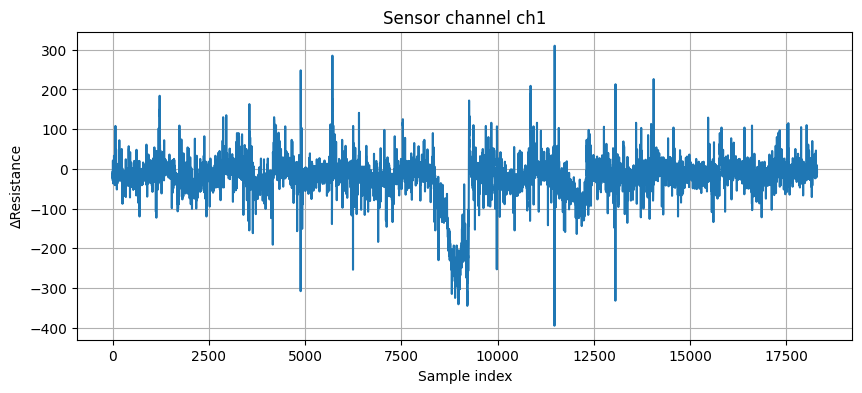

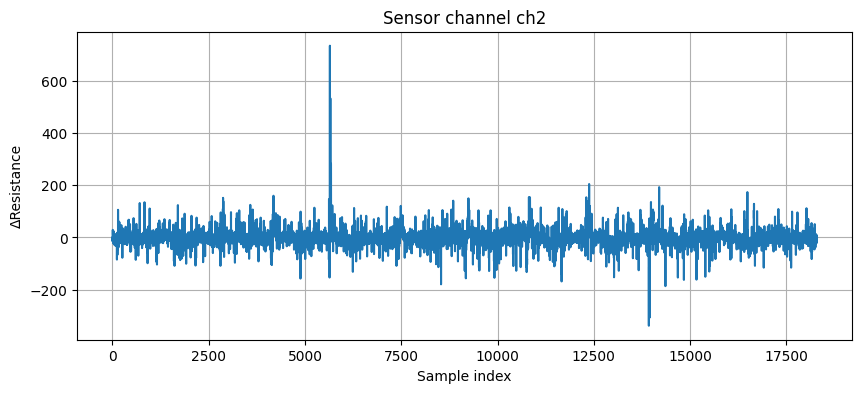

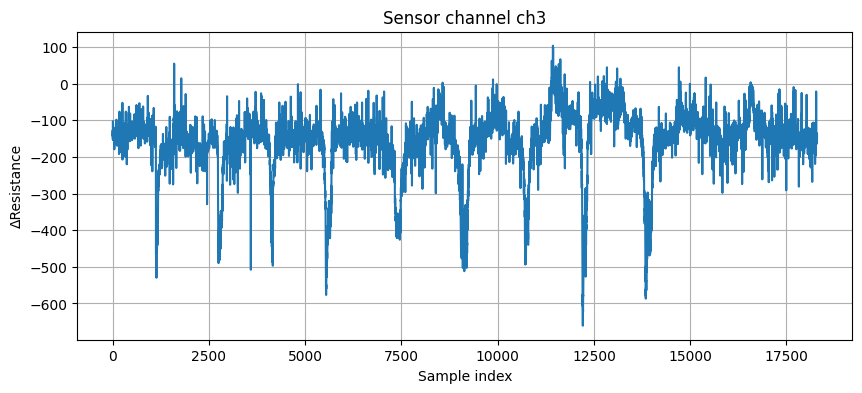

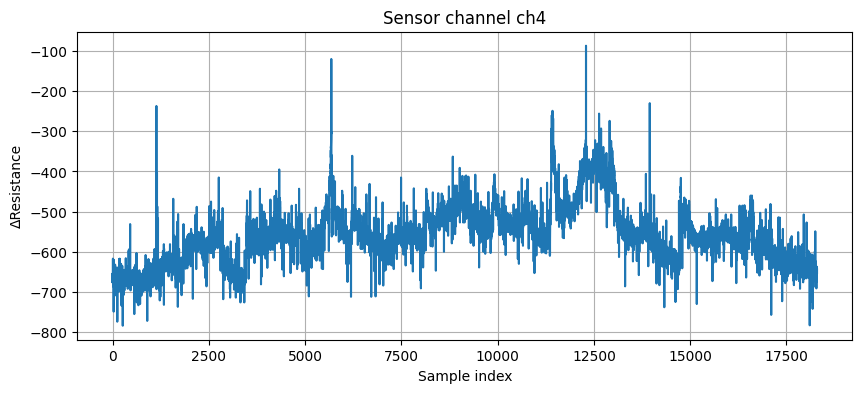

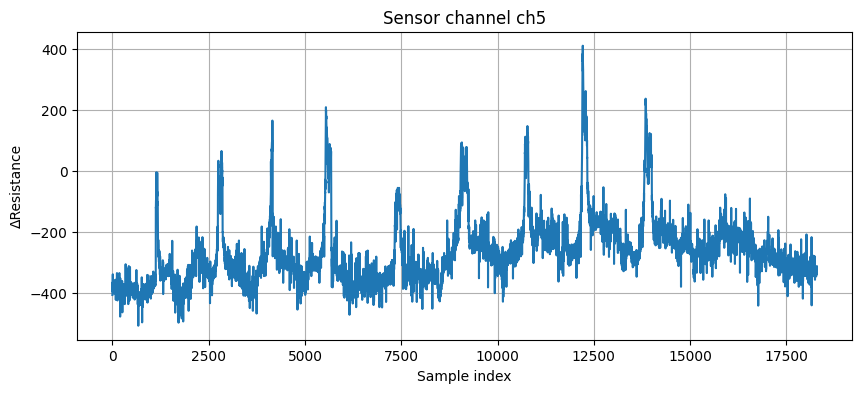

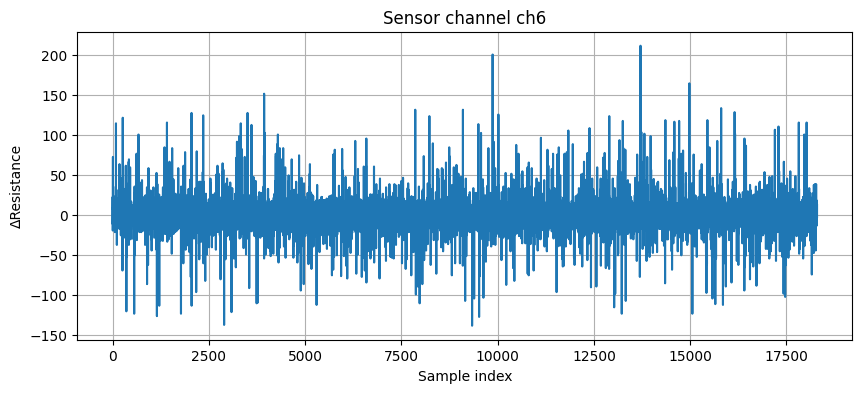

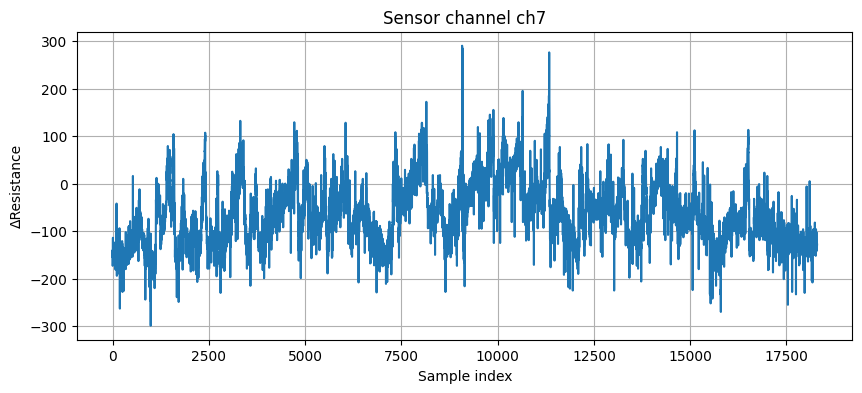

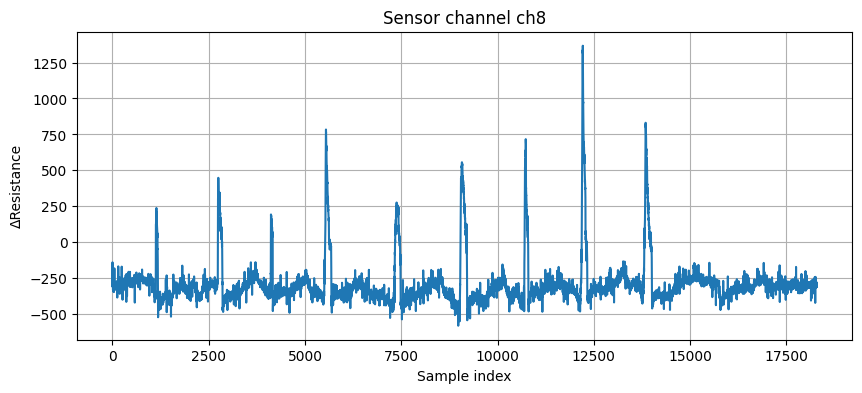

In [15]:
import matplotlib.pyplot as plt

channels = ["ch1","ch2","ch3","ch4","ch5","ch6","ch7","ch8"]

for ch in channels:
    plt.figure(figsize=(10,4))
    plt.plot(df1[ch])  # по оси X автоматически индекс 0..N-1
    plt.title(f"Sensor channel {ch}")
    plt.xlabel("Sample index")
    plt.ylabel("ΔResistance")
    plt.grid(True)
    plt.show()


In [16]:
import numpy as np

In [17]:
X = np.array(df1['ch8'])

In [18]:
df1.to_csv('../../datasets/matlab_test.csv', index=False)

In [19]:
from scipy.signal import butter, filtfilt

def butter_lowpass_filter(data, cutoff, fs, order=4):
    nyq = 0.5 * fs           # частота Найквиста
    normal_cutoff = cutoff / nyq
    
    # проектируем фильтр
    b, a = butter(order, normal_cutoff, btype='low', analog=False)

    #win = 500
    #data = np.pad(data, win//2, mode='edge')
    #data = np.convolve(data, np.ones(win)/win, mode='same')
    #data = data[win//2:win//2+1]
    
    # применяем фильтр без фазовых искажений
    filtered = filtfilt(b, a, data)
    return filtered

# пример использования
#filtered_signal = butter_lowpass_filter(X, cutoff=2, fs=500)
filtered_signal_all = []
col = ['ch1','ch2','ch3','ch4','ch5','ch6','ch7','ch8']
for i in col:
    filtered_signal = butter_lowpass_filter(np.array(df1[i]), cutoff=2.5, fs=500)
    filtered_signal_all.append(filtered_signal)

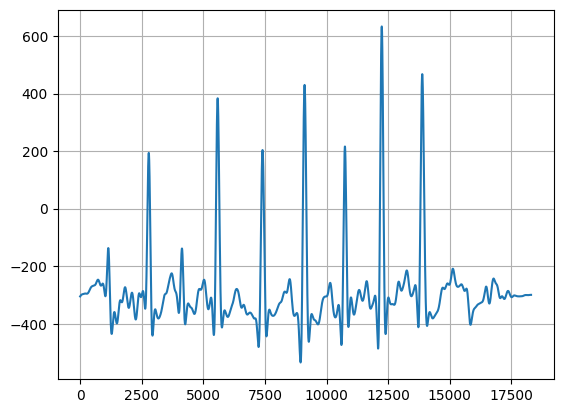

In [20]:
plt.plot(filtered_signal)
plt.grid()

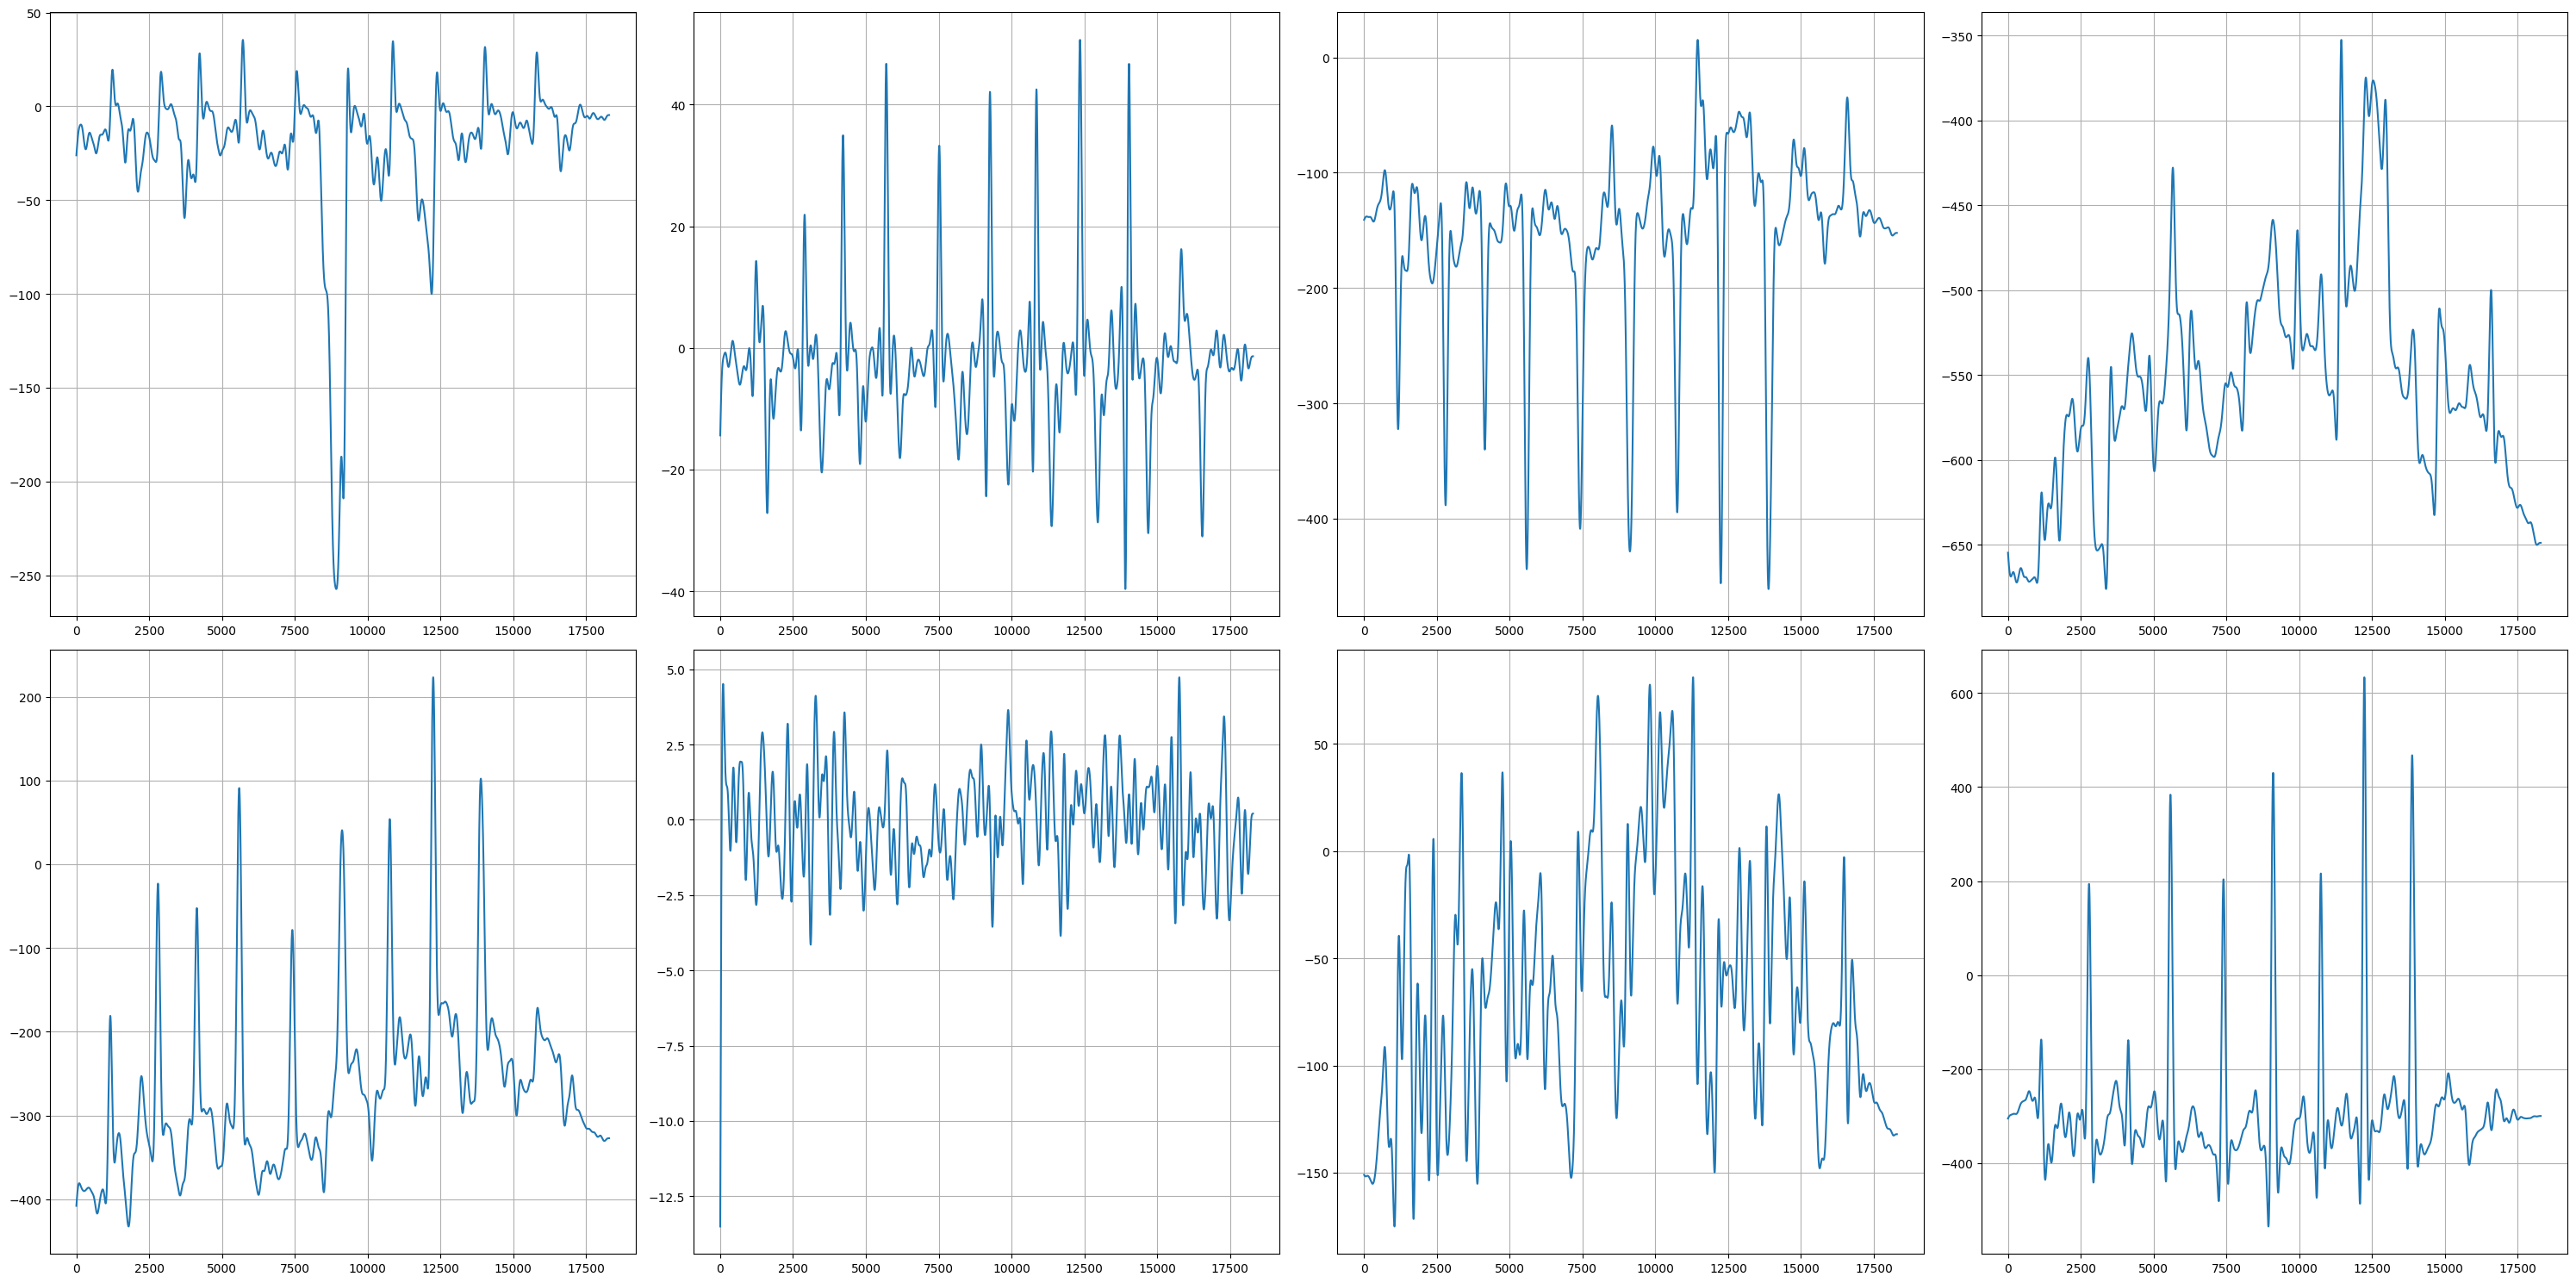

In [21]:
plt.figure(figsize=(30, 15))  # размер всей фигуры

for i, signal in enumerate(filtered_signal_all):    
    plt.subplot(2, 4, i+1)
    plt.plot(signal)
    plt.grid()

plt.tight_layout()
plt.show()

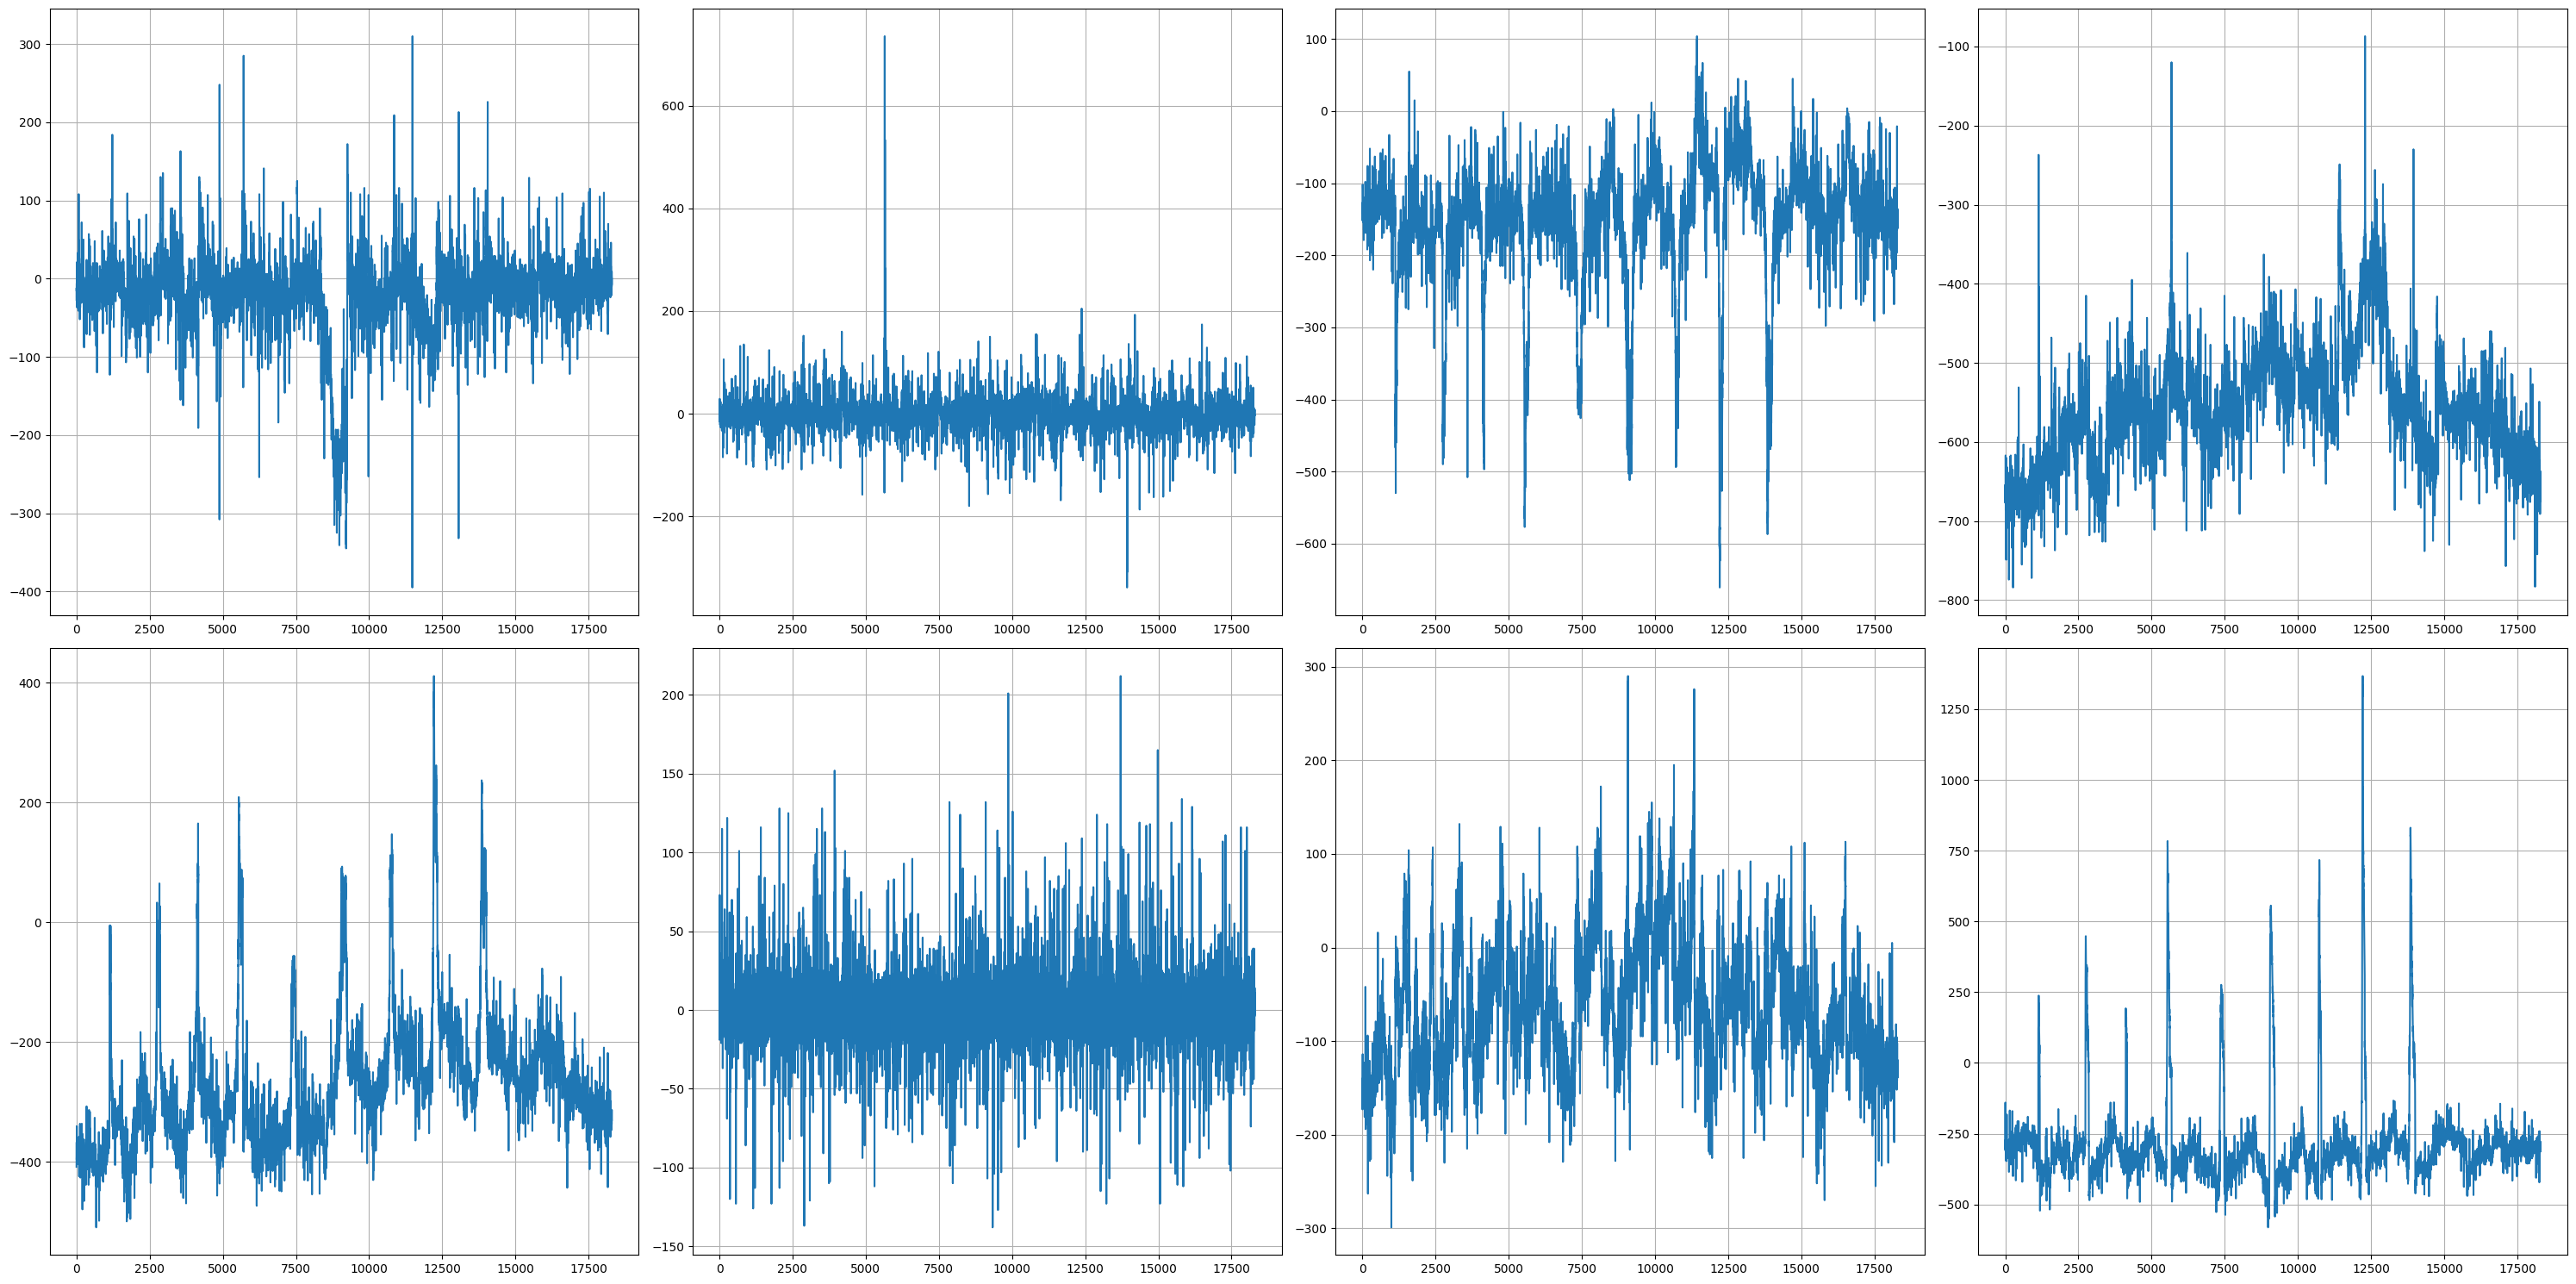

In [22]:
plt.figure(figsize=(30, 15))  # размер всей фигуры

for i, signal in enumerate(filtered_signal_all):    
    plt.subplot(2, 4, i+1)
    plt.plot(np.array(df1.iloc[:,i+1]))
    plt.grid()

plt.tight_layout()
plt.show()

In [23]:
from scipy.signal import decimate

fs_old = 500
fs_new = 10
decim_factor = int(round(fs_old / fs_new))  # ≈31

#X_down = decimate(X, decim_factor, axis=0, ftype='iir')
decim_signal_all = []
col = ['ch1','ch2','ch3','ch4','ch5','ch6','ch7','ch8']
for i in col:
    decim_signal = decimate(np.array(df1[i]), decim_factor, axis=0, ftype='fir')
    decim_signal_all.append(decim_signal)

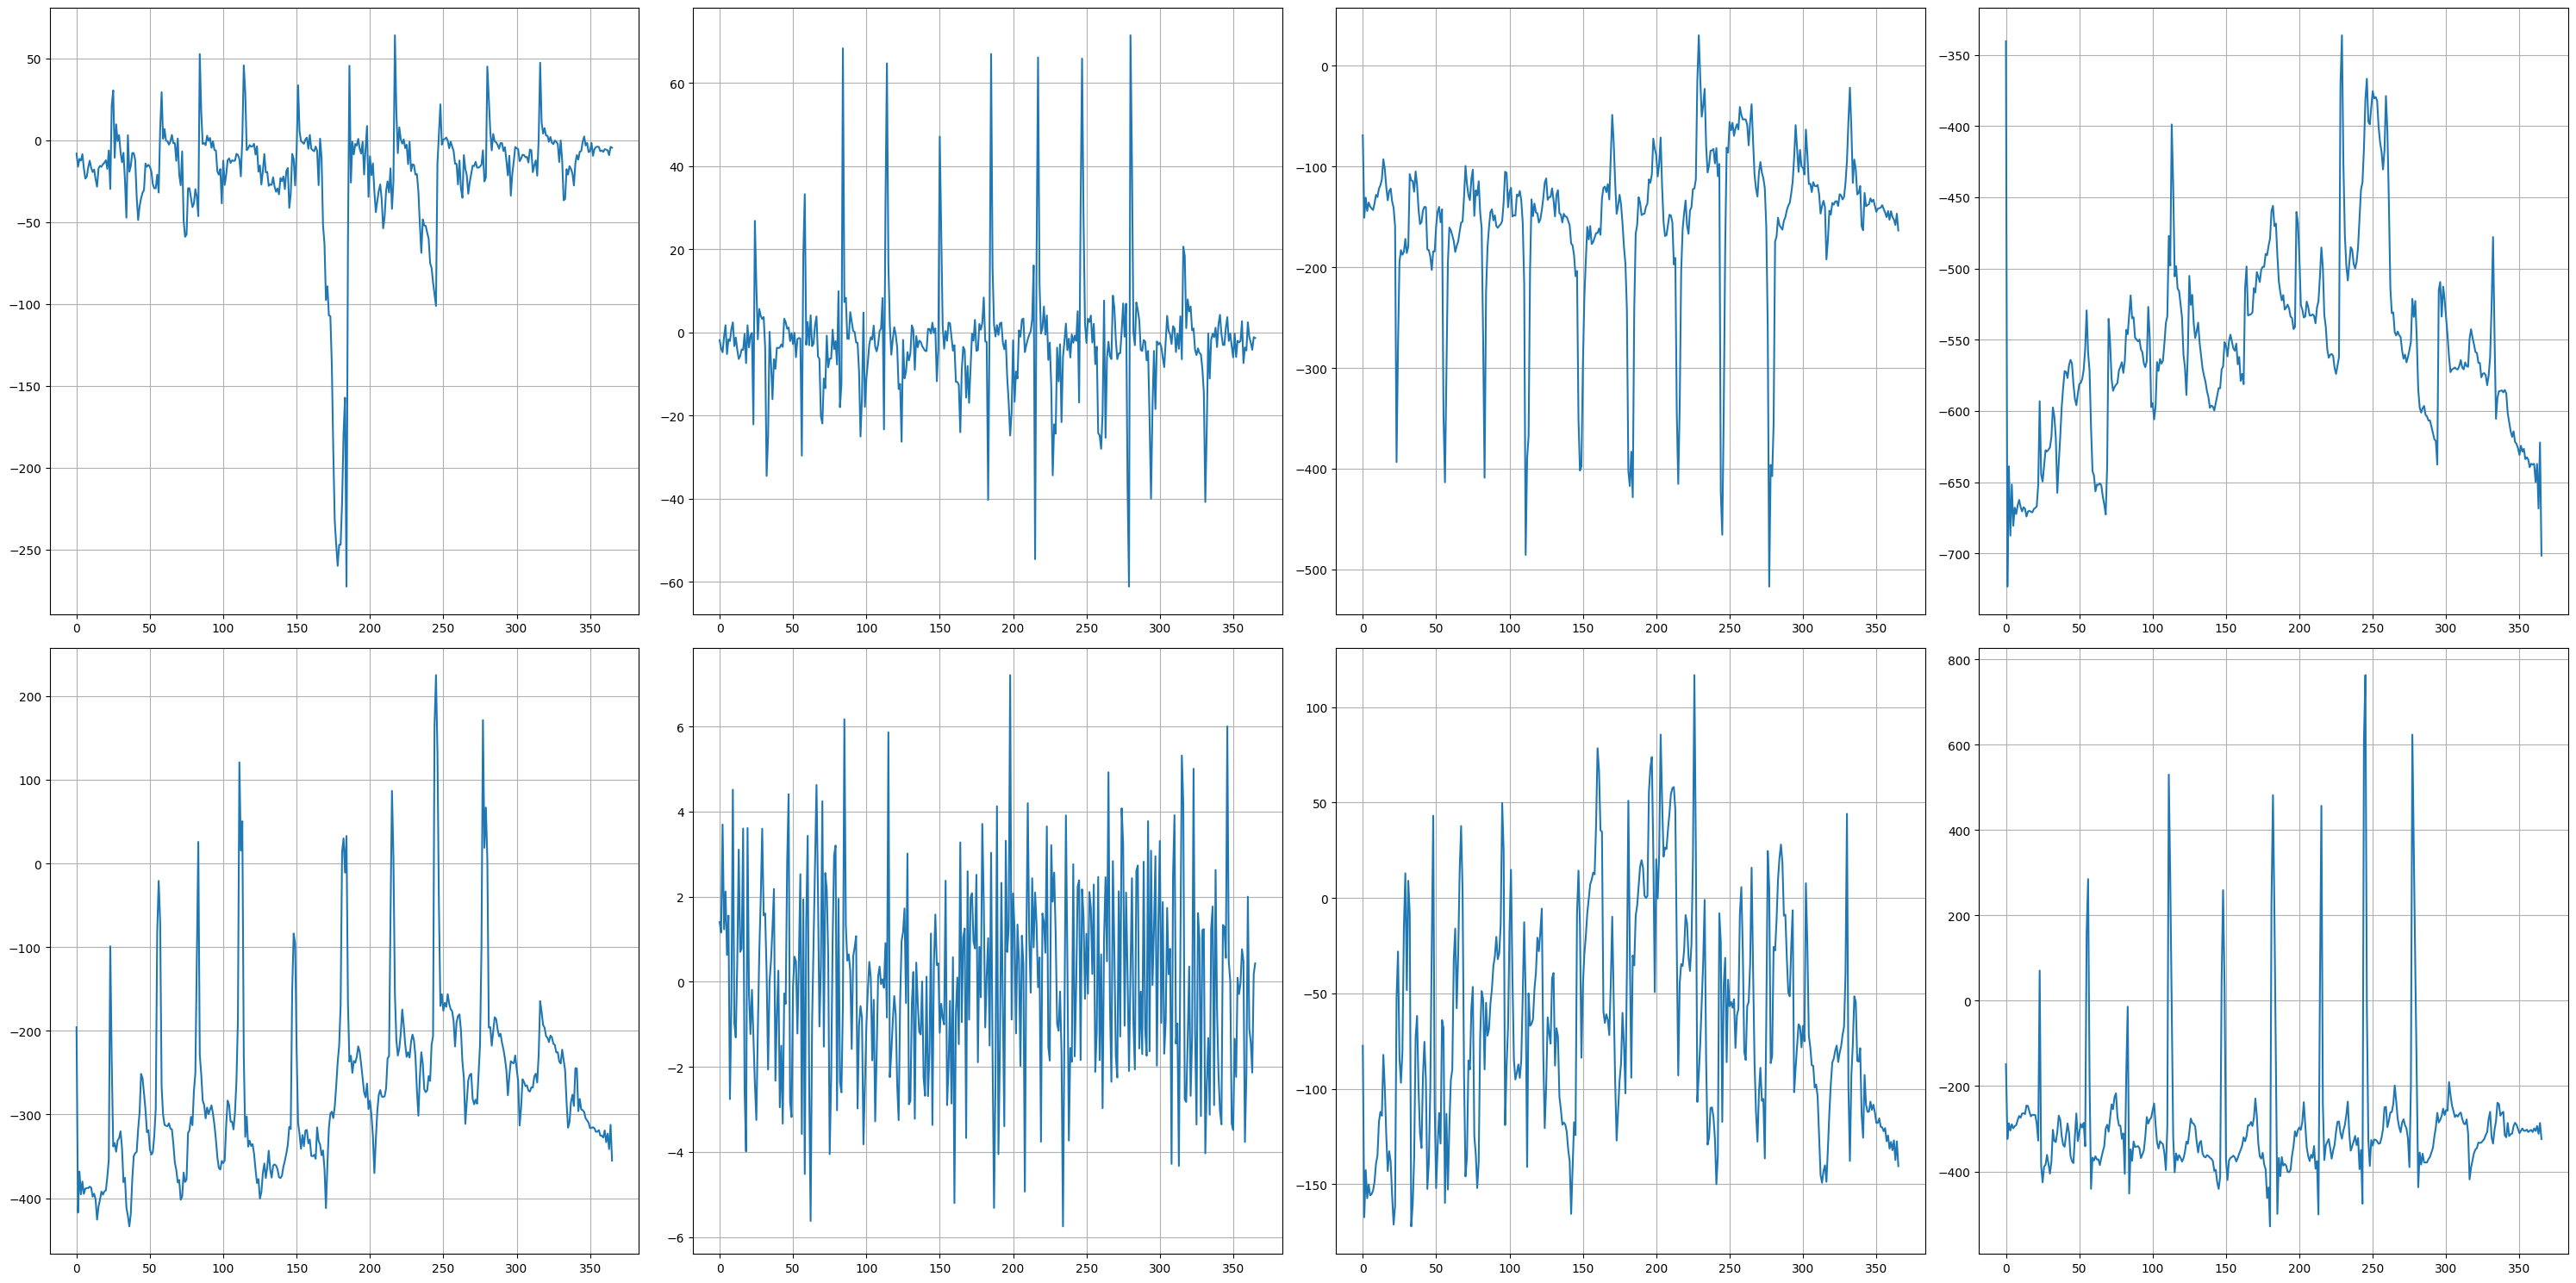

In [24]:
plt.figure(figsize=(30, 15))  # размер всей фигуры

for i, signal in enumerate(decim_signal_all):    
    plt.subplot(2, 4, i+1)
    plt.plot(signal)
    plt.grid()

plt.tight_layout()
plt.show()

In [25]:
from scipy.signal import decimate

fs_old = 500
fs_new = 20
decim_factor = int(round(fs_old / fs_new))  # ≈31

#X_down = decimate(X, decim_factor, axis=0, ftype='iir')
decim_signal_all_hand = []

for i in filtered_signal_all:
    decim_signal = i[::decim_factor]
    decim_signal_all_hand.append(decim_signal)

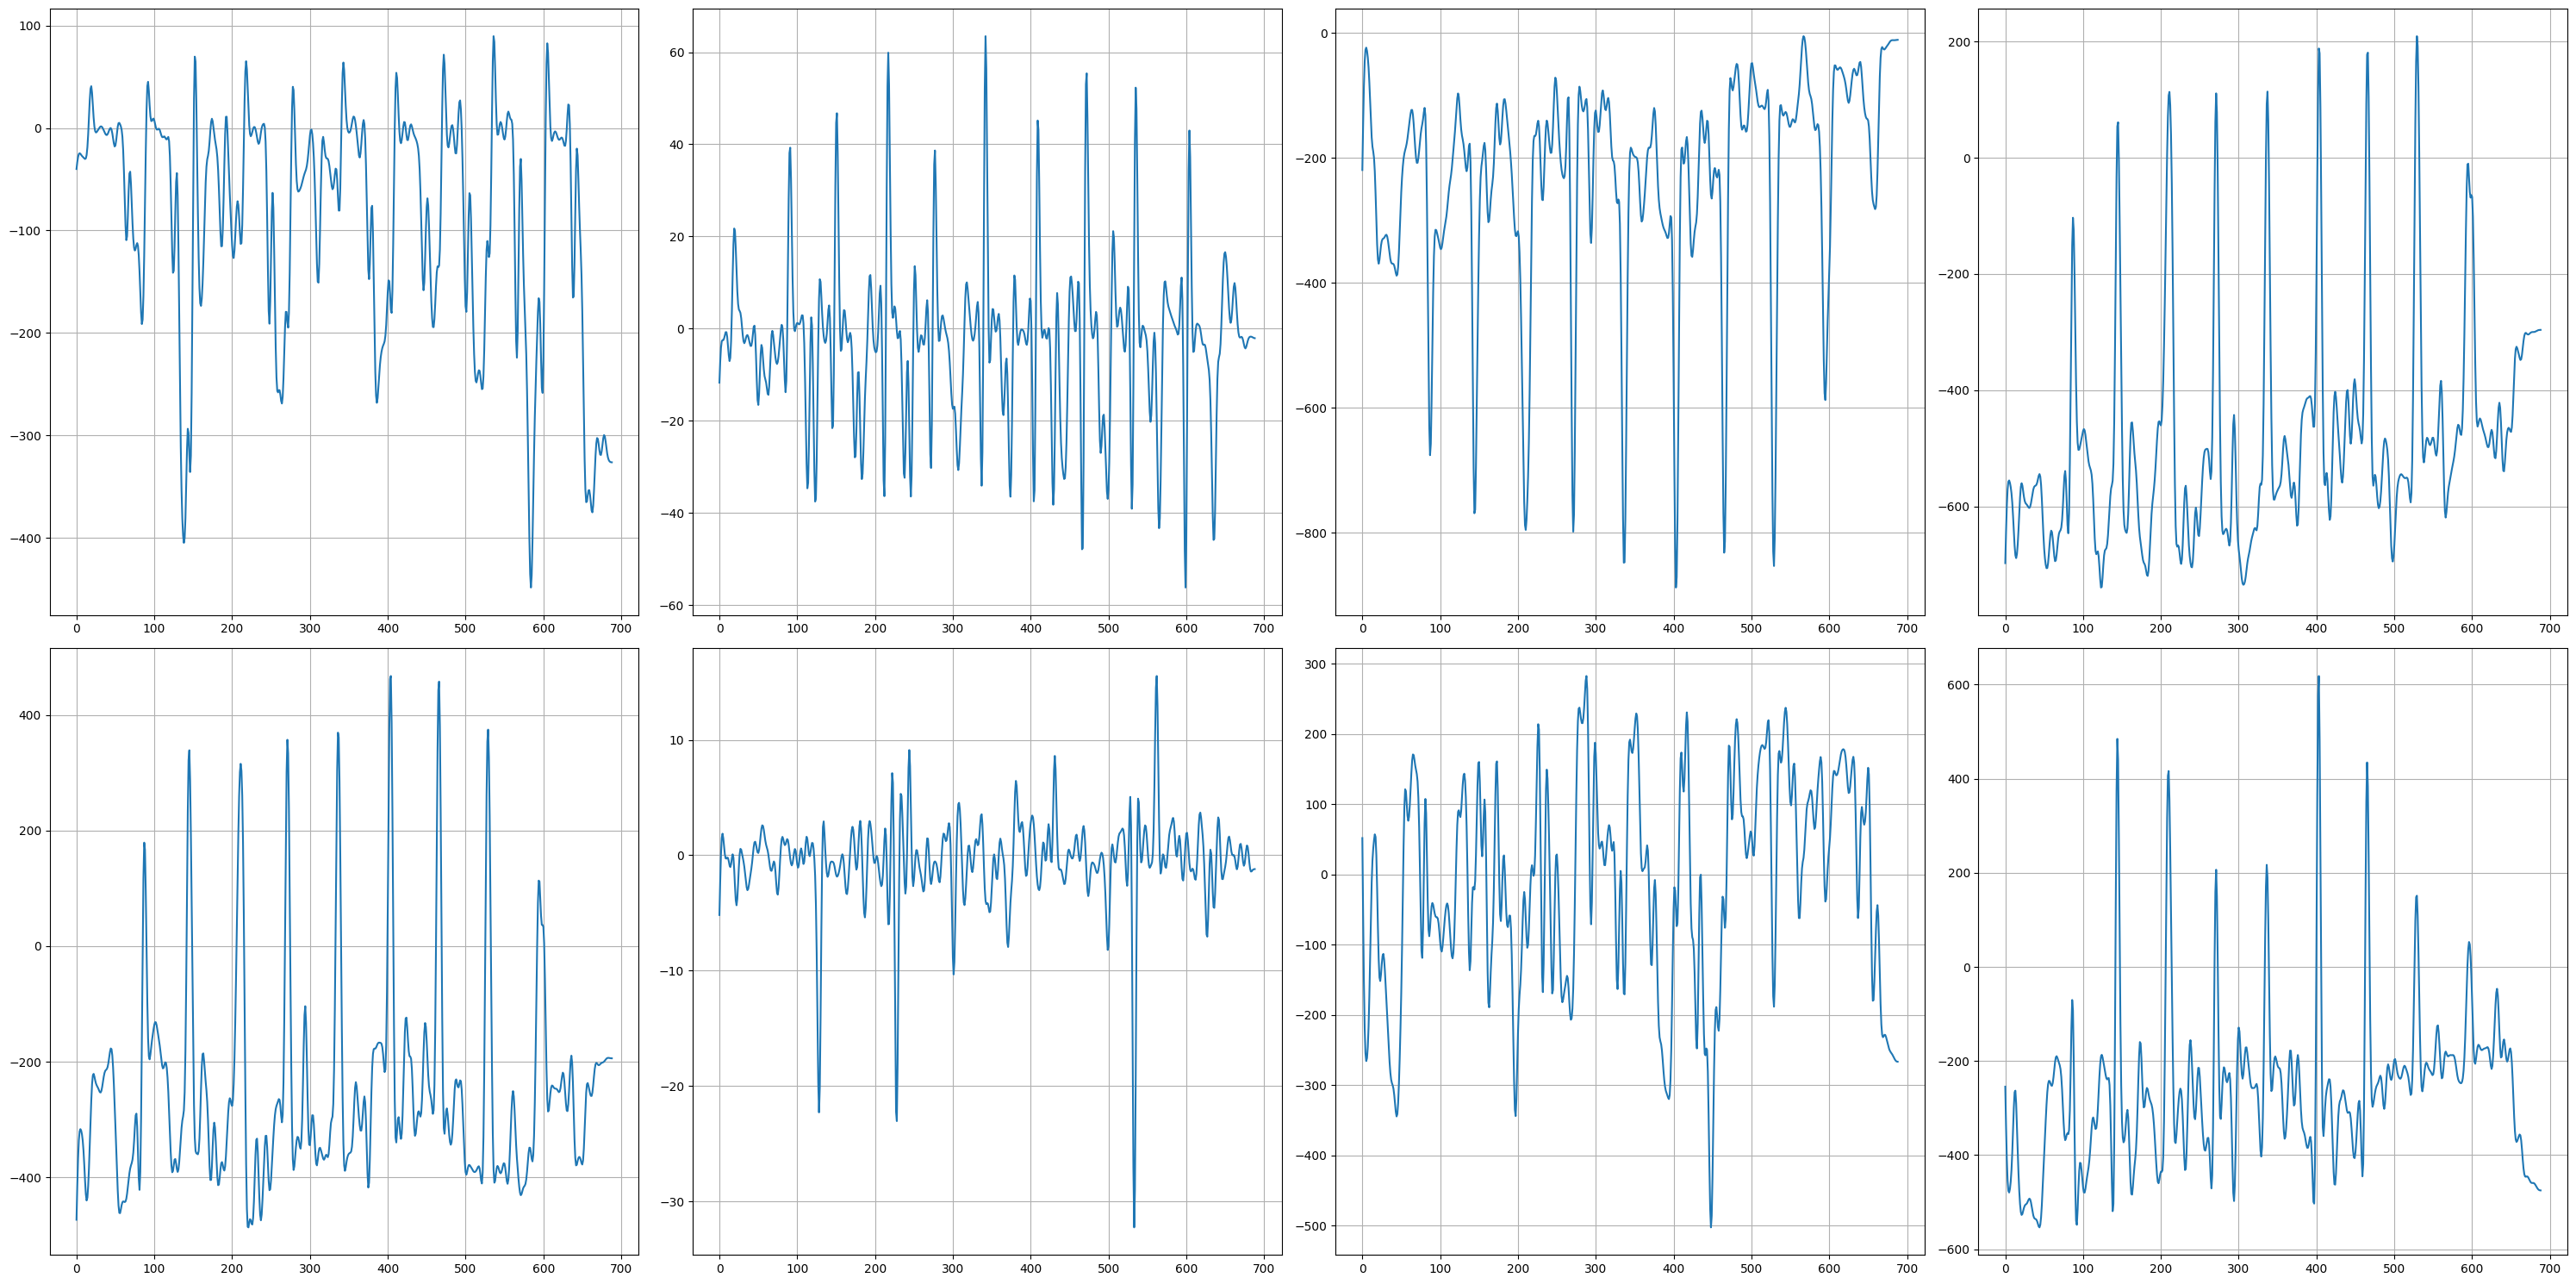

In [51]:
plt.figure(figsize=(30, 15))  # размер всей фигуры

for i, signal in enumerate(decim_signal_all_hand):    
    plt.subplot(2, 4, i+1)
    plt.plot(signal)
    plt.grid()

plt.tight_layout()
#plt.savefig("равновесия на двух.png", dpi=300)
plt.show()


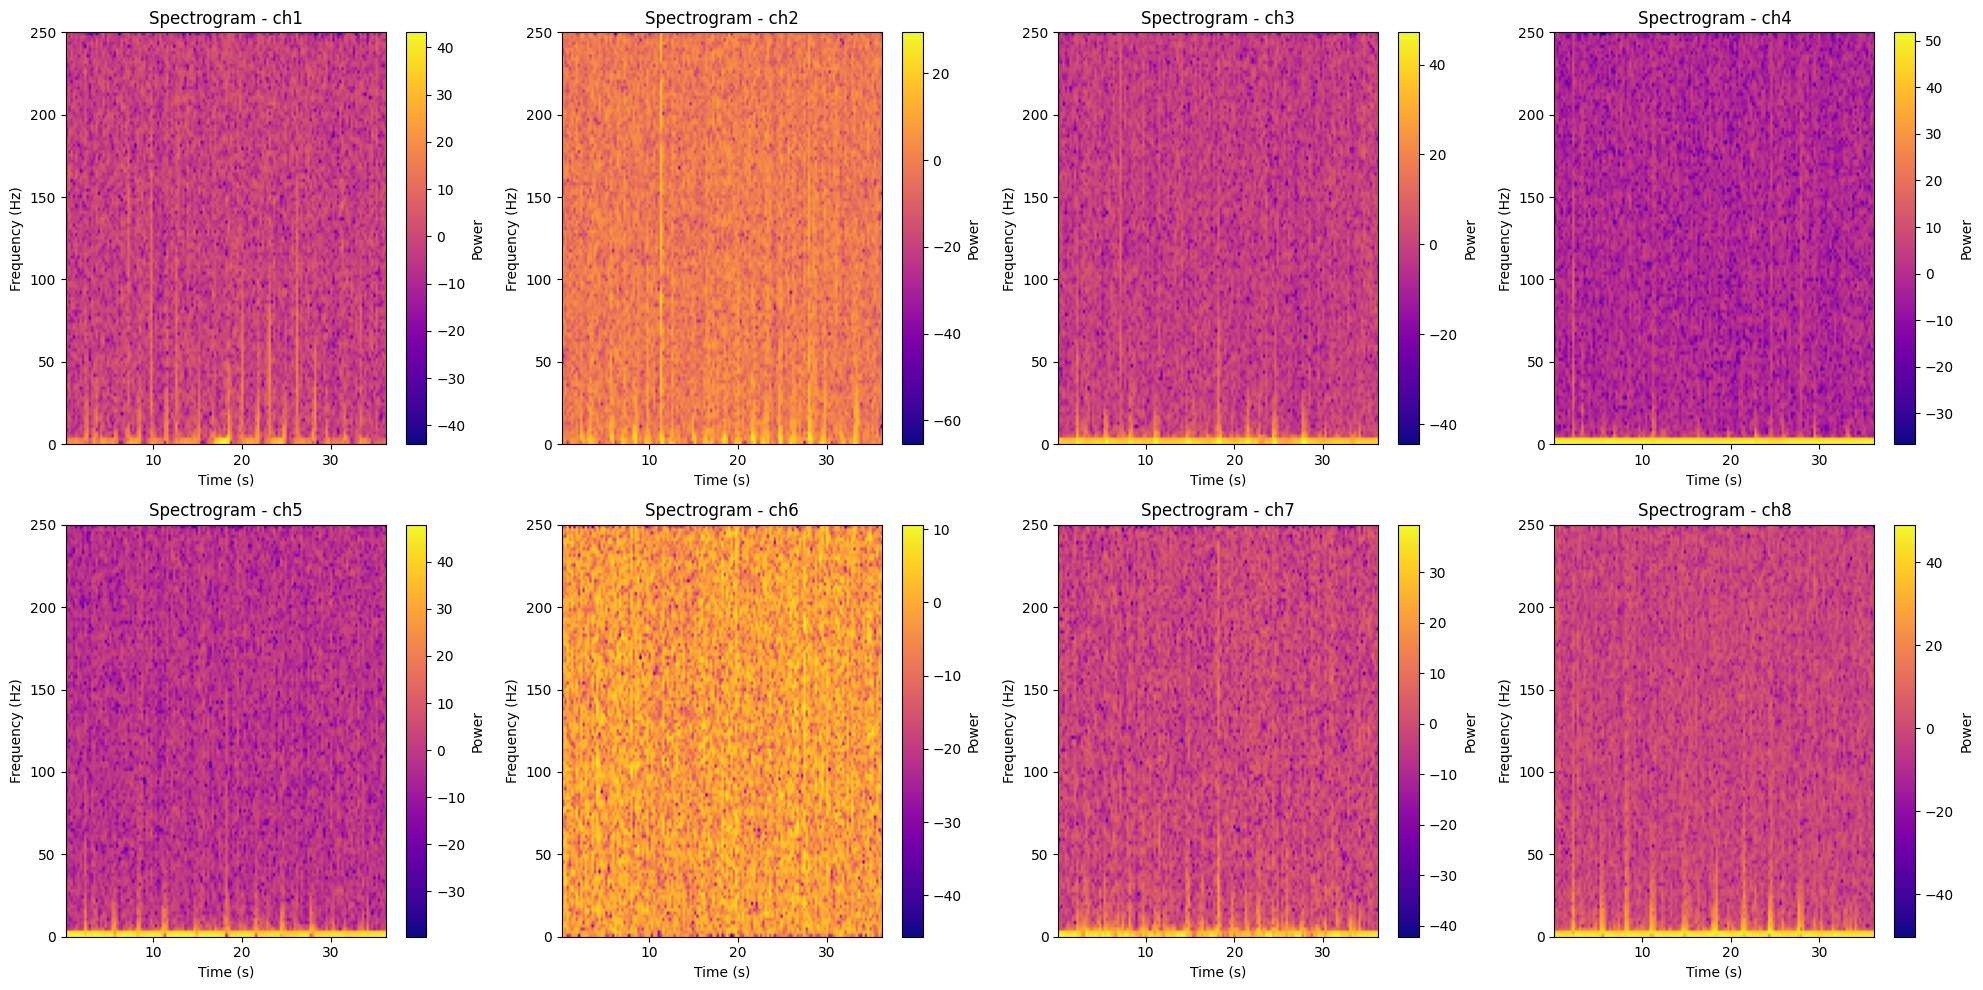

In [27]:
import matplotlib.pyplot as plt

fs = 500  # частота дискретизации

channels = [f'ch{i}' for i in range(1, 9)]  # ['ch1', 'ch2', ..., 'ch8']

plt.figure(figsize=(20, 10))  # размер всей фигуры

for i, ch in enumerate(channels, 1):
    signal = df1[ch].values
    plt.subplot(2, 4, i)
    plt.specgram(signal, NFFT=256, Fs=fs, noverlap=128, cmap='plasma')
    plt.title(f"Spectrogram - {ch}")
    plt.xlabel("Time (s)")
    plt.ylabel("Frequency (Hz)")
    plt.colorbar(label="Power")  # отдельная цветовая шкала для каждого графика

plt.tight_layout()
plt.show()


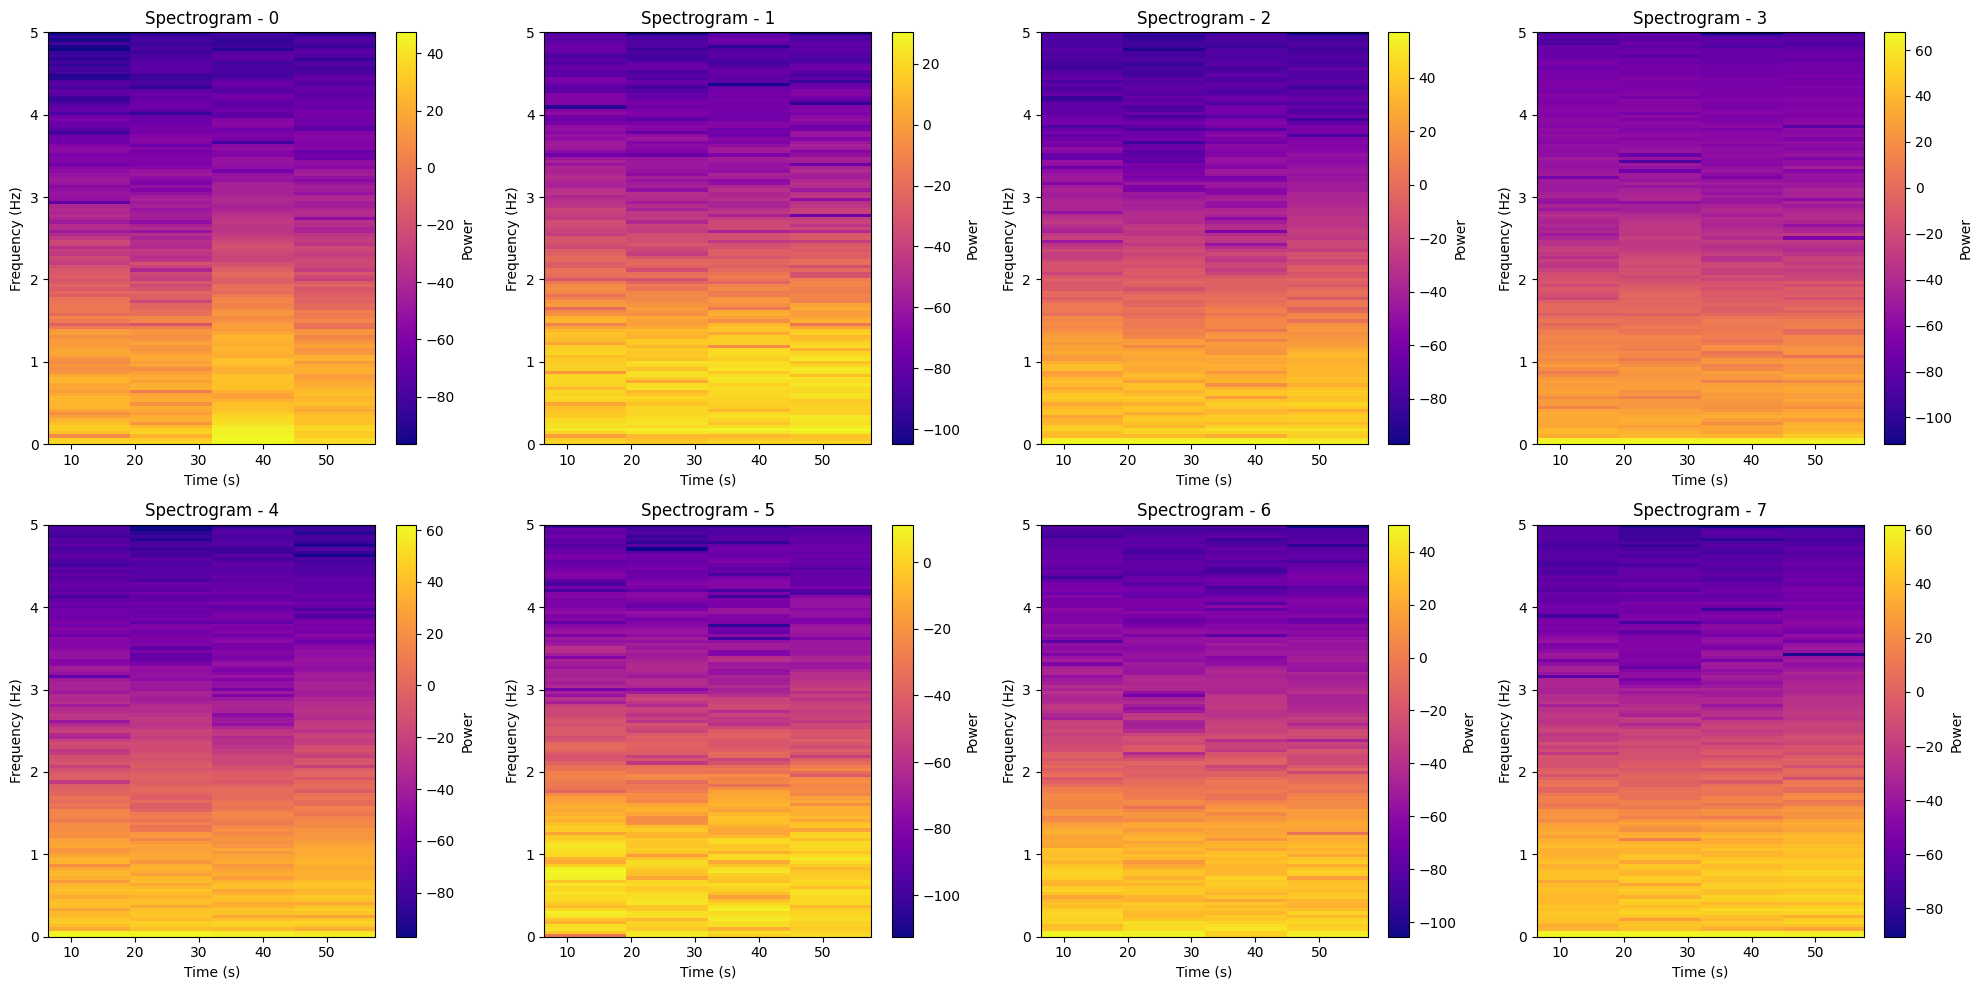

In [28]:
fs = 10 


plt.figure(figsize=(20, 10))  # размер всей фигуры

#plt.figure(figsize=(30, 15))  # размер всей фигуры

for i, signal in enumerate(decim_signal_all_hand):    
    plt.subplot(2, 4, i+1)
    plt.specgram(signal, NFFT=256, Fs=fs, noverlap=128, cmap='plasma')
    plt.title(f"Spectrogram - {i}")
    plt.xlabel("Time (s)")
    plt.ylabel("Frequency (Hz)")
    plt.colorbar(label="Power")  # отдельная цветовая шкала для каждого графика

plt.tight_layout()
plt.show()

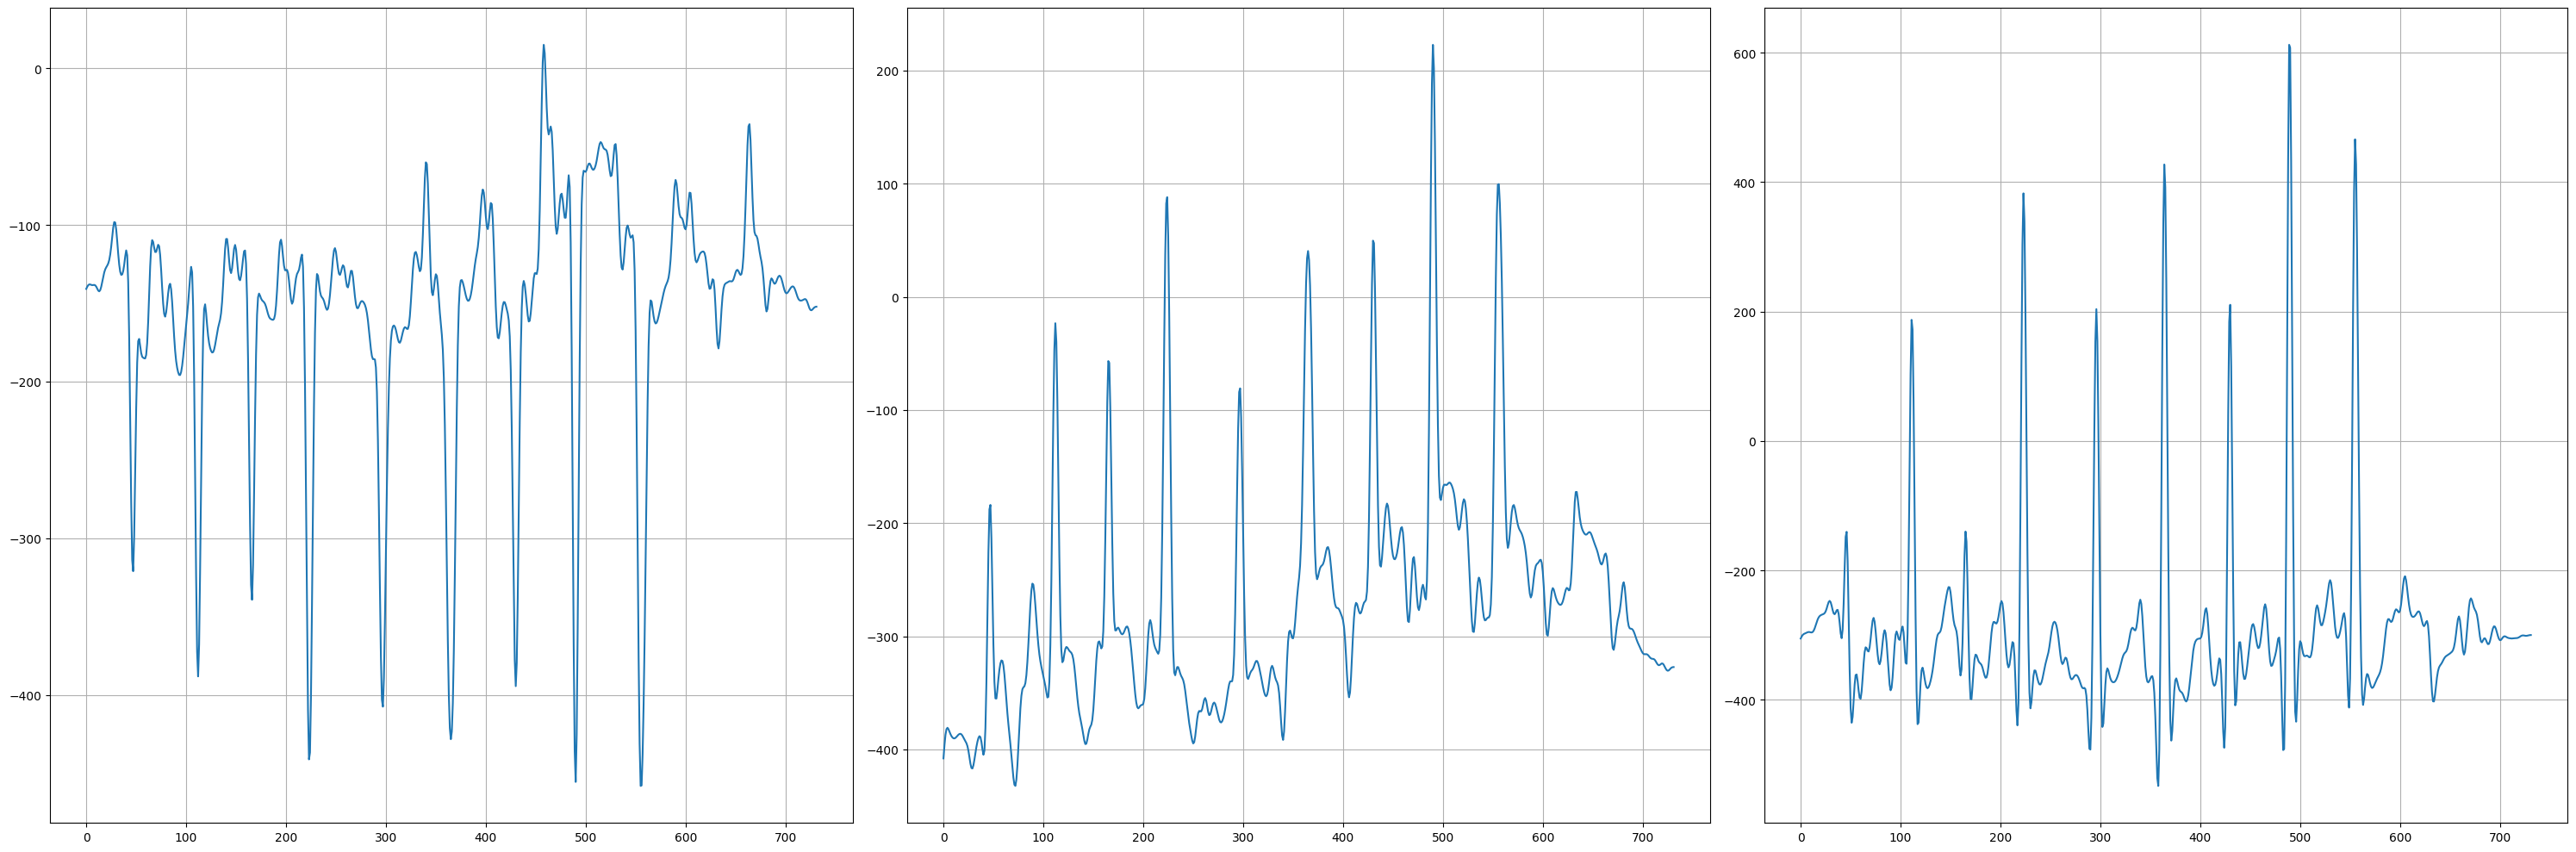

In [29]:
plt.figure(figsize=(30, 10))  # размер всей фигуры

plt.subplot(1, 3, 1)
plt.plot(decim_signal_all_hand[2])
plt.grid()

plt.subplot(1, 3, 2)
plt.plot(decim_signal_all_hand[4])
plt.grid()

plt.subplot(1, 3, 3)
plt.plot(decim_signal_all_hand[7])
plt.grid()

plt.tight_layout()
#plt.savefig("10 шагов 1 детекция шага.png", dpi=300)
plt.show()


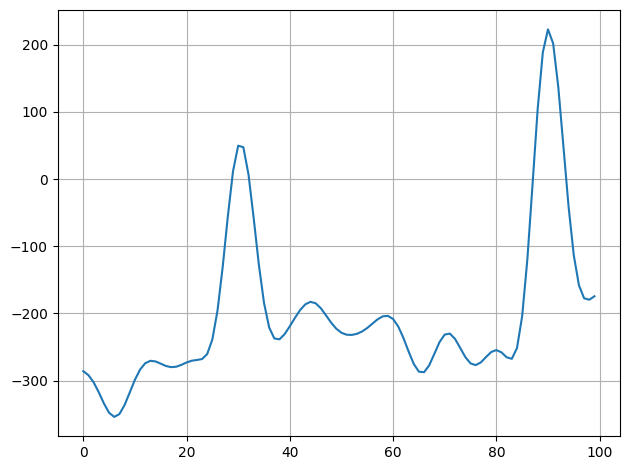

In [30]:
plt.plot(decim_signal_all_hand[4][400:500])
plt.grid()

plt.tight_layout()
#plt.savefig("10 шагов 1 детекция шага.png", dpi=300)
plt.show()


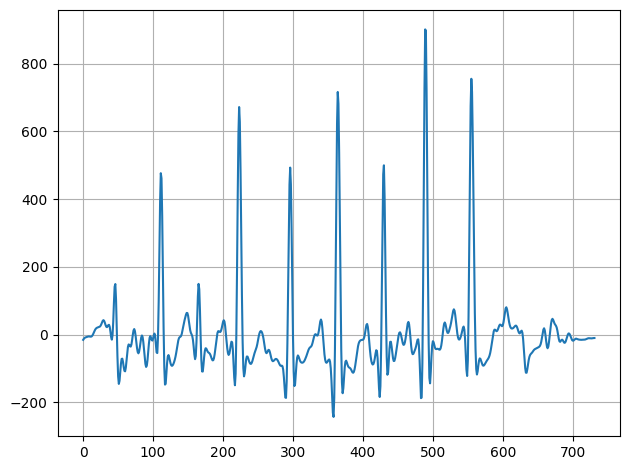

In [31]:
signal = decim_signal_all_hand[7]

detail = signal - np.mean(signal)

plt.plot((detail))
plt.grid()

plt.tight_layout()
#plt.savefig("10 шагов 1 детекция шага.png", dpi=300)
plt.show()

In [32]:
def autocorr(x):
    x = np.asarray(x)
    x = x - x.mean()
    result = np.correlate(x, x, mode='full')
    return result[result.size//2:] / result[result.size//2]

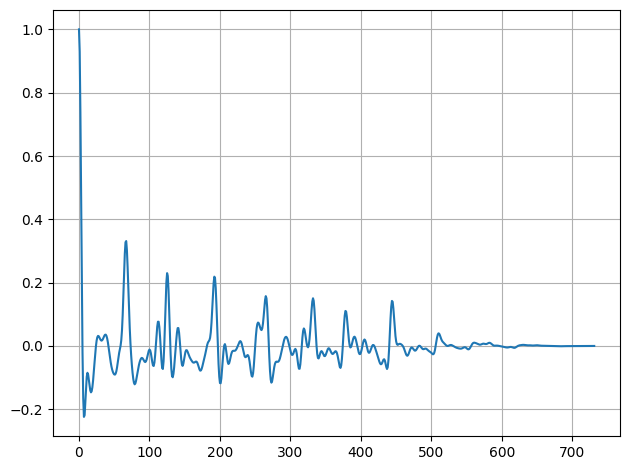

In [33]:
detail = autocorr(detail)

plt.plot((detail))
plt.grid()

plt.tight_layout()
#plt.savefig("10 шагов 1 детекция шага.png", dpi=300)
plt.show()

In [34]:
def moving_average(x, w):
    return np.convolve(x, np.ones(w)/w, mode='same')

In [35]:
peaks, _ = find_peaks(signal3-np.mean(signal3), distance=40,height=400)

NameError: name 'find_peaks' is not defined

In [ ]:
signal = decim_signal_all_hand[7]

In [ ]:
peaks_for_peaks = [46,111,165,223,296, 364, 430, 489, 555]

In [ ]:
figures = []
for peak in peaks_for_peaks:
    figures.append(signal[peak-9:peak+10])

In [ ]:
df_10 = pd.DataFrame({
    "ch1": signal1,
    "ch2": signal2,
    "ch3": signal3
})
df_10.to_csv('../../datasets/10_шагов_1_matlab.csv', index=False)

In [ ]:
signal1 = decim_signal_all_hand[2]
signal2 = decim_signal_all_hand[4]
signal3 = decim_signal_all_hand[7]

In [ ]:
detail = signal3

In [ ]:
dy = np.gradient((detail))

In [ ]:
plt.plot(dy)
#plt.plot(dyX)
plt.grid()
plt.show()

In [ ]:
if np.abs(np.max(dy))>np.abs(np.min(dy)):
    dyX = (np.where(dy<0,0,dy))
else:
    dyX = (np.where(-dy<0,0,-dy))

In [ ]:
def autocorr_unbiased(x):
    x = x - np.mean(x)
    N = len(x)
    result = np.correlate(x, x, mode='full')
    ac = result[result.size//2:]
    unbiased = ac / (N - np.arange(N))   # <-- ключ!
    return unbiased / unbiased[0]

In [ ]:
cor = autocorr_unbiased(dyX)

plt.plot(cor)
#plt.plot(dyX)
plt.grid()
plt.show()

In [ ]:
#
if np.abs(np.max(dy))>np.abs(np.min(dy)):
    dyX = (np.where(dy<0,0,dy))
else:
    dyX = (np.where(-dy<0,0,-dy))

In [ ]:
dyX = np.where(dy < 0, 0, dy)

In [ ]:
plt.plot(dyX)
#plt.plot(dyX)
plt.grid()
plt.show()

In [ ]:
dy = np.gradient((dyX))
plt.plot(np.where(dy < 0, 0, dy))
#plt.plot(dyX)
plt.grid()
plt.show()

In [ ]:
#signal_check = moving_average(abs(dyX),4)
signal_check = dyX
signal_check = (signal_check/np.max(signal_check)) #
plt.plot(signal_check)
#plt.plot(dyX)
plt.grid()
plt.show()

In [ ]:
np.mean(signal_check)

In [ ]:
#signal_check2 = autocorr(signal_check)  2048 - 0.99

In [622]:
signal_check2 = signal_check**8
signal_check2 = (2**20)*signal_check2/2048
#signal_check2 = signal_check * np.exp(*signal_check**2) ####1.5
signal_check2 = np.where(signal_check2>1, 1, signal_check2)

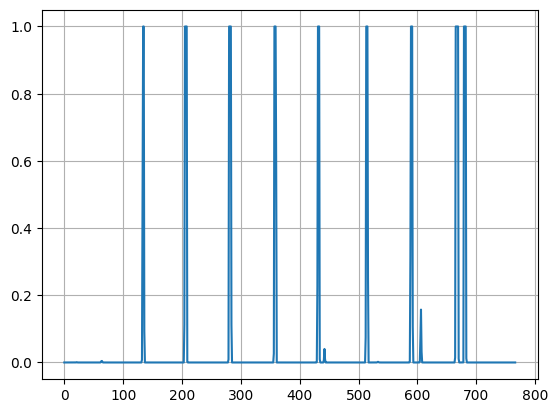

In [623]:
plt.plot(signal_check2)
#plt.plot(dyX)
plt.grid()
plt.show()

In [65]:
from scipy.signal import find_peaks

peaks, _ = find_peaks(signal_check2, distance=5,height=0.9)

In [66]:
peaks

array([ 44, 108, 163, 220, 293, 361, 427, 487, 552], dtype=int64)

In [67]:
peaks.shape

(9,)

In [508]:
np.sum(signal_check>np.mean(signal_check)*3.5)

45

In [140]:
np.mean(signal_check)

6.6300069314396595

In [20]:
decim_signal_all_hand[2][46]

-313.8640681382231

In [21]:
decim_signal_all_hand[4][46]

-187.845250834658

In [22]:
decim_signal_all_hand[7][46]

-140.3418224269512

In [23]:
def moving_average(x, w):
    return np.convolve(x, np.ones(w)/w, mode='same')

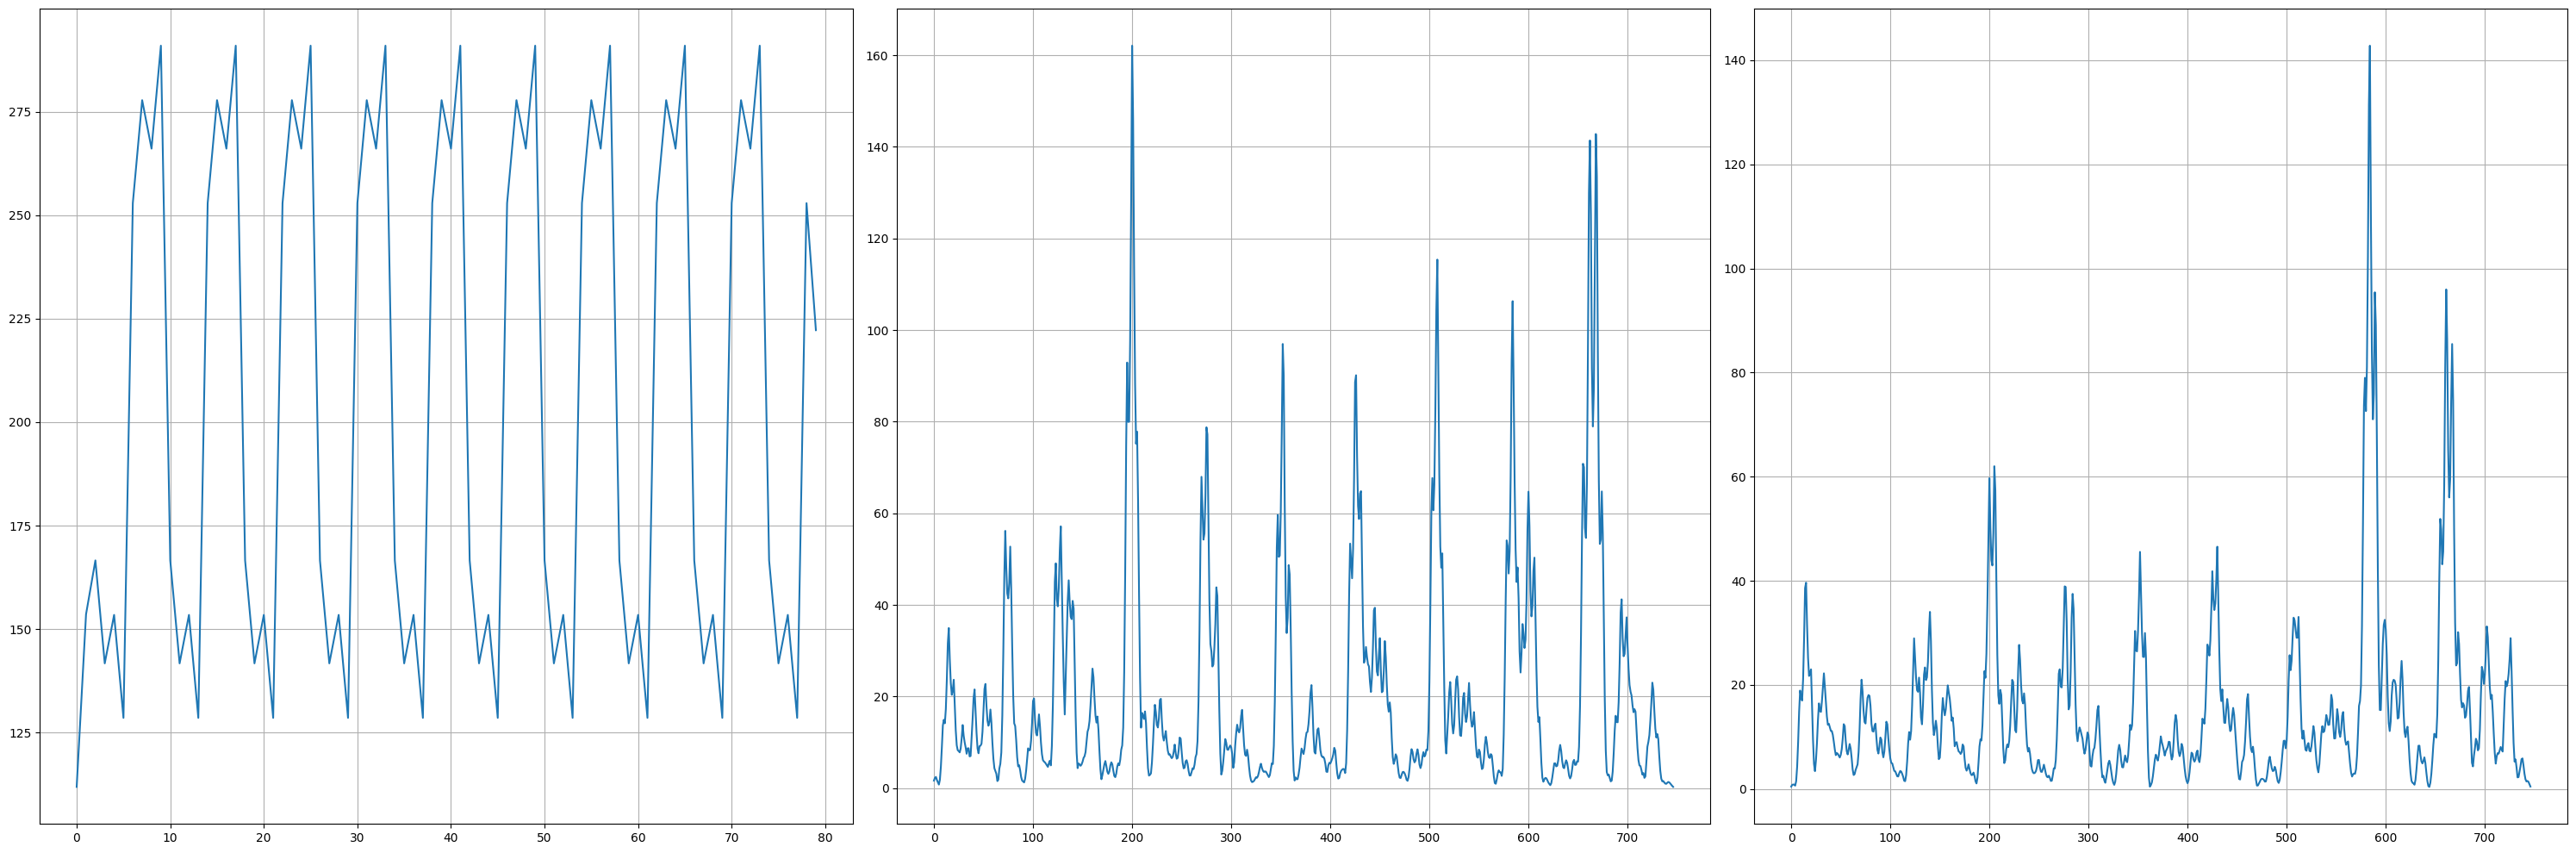

In [700]:
import numpy as np
import pywt
from scipy.signal import find_peaks
import matplotlib.pyplot as plt

def find_peaks_signal(signal):
    #signal = decim_signal_all_hand[7]

    # ----- 1. Вейвлет-преобразование -----
    # Daubechies 4: хорошо выделяет резкие обрывы
    wavelet = 'mexh'  # Continuous wavelet

    scales = np.arange(1, 10)

    # CWT возвращает матрицу: scale × time
    coeffs, freqs = pywt.cwt(signal, scales, wavelet)

    # Обычно выбирают один «оптимальный» масштаб: например scale=15
    cwt_level = coeffs[0]
    return cwt_level

    #peaks, _ = find_peaks(cwt_level, height=110, distance=5)

# ----- 3. Визуализация -----
#plt.figure(figsize=(16,6))

#plt.subplot(2,1,1)
#plt.title("Сигнал")
#plt.plot(signal)
#plt.scatter(peaks, signal[peaks], color='red')
#plt.grid()

#plt.subplot(2,1,2)
#plt.title("CWT (scale=15) — пики более явные")
#plt.plot(cwt_level)
#plt.scatter(peaks, cwt_level[peaks], color='red')
#plt.grid()

plt.figure(figsize=(30, 10))  # размер всей фигуры

signal = np.zeros(100)
signal[::8] = 500
signal[1::8] = 600
signal[2::8] = 100

new_signal = find_peaks_signal(signal)
plt.subplot(1, 3, 1)
plt.plot(moving_average(np.abs(new_signal[10:-10]),4))
plt.grid()

signal_find_peaks1 = moving_average(np.abs(new_signal[10:-10]),4)

new_signal = find_peaks_signal(decim_signal_all_hand[4])
plt.subplot(1, 3, 2)
plt.plot(moving_average(np.abs(new_signal[10:-10]),4))
plt.grid()

signal_find_peaks2 = moving_average(np.abs(new_signal[10:-10]),4)

new_signal = find_peaks_signal(decim_signal_all_hand[7])
plt.subplot(1, 3, 3)
plt.plot(moving_average(np.abs(new_signal[10:-10]),4))
plt.grid()

signal_find_peaks3 = moving_average(np.abs(new_signal[10:-10]),4)

plt.tight_layout()
#plt.savefig("10 шагов 1 вейвлет + модуль + сглаживание.png", dpi=300)
plt.show()



In [34]:
dy = np.gradient((signal_find_peaks1))

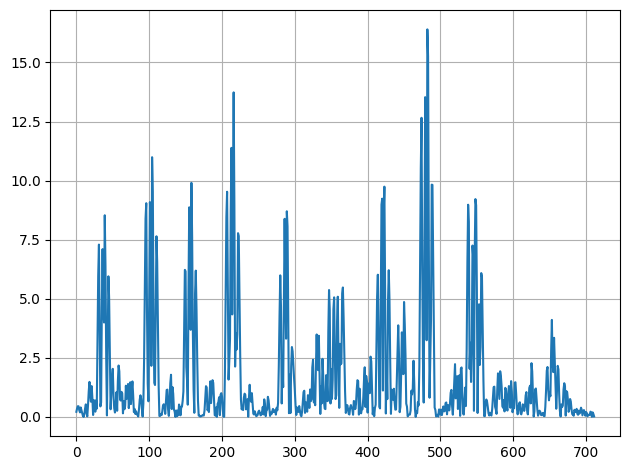

In [35]:
plt.plot(abs(dy))
plt.grid()

plt.tight_layout()
#plt.savefig("10 шагов 1 детекция шага.png", dpi=300)
plt.show()

In [32]:
np.mean(signal_find_peaks1)  #2,5,2,1.5

9.28039051508137

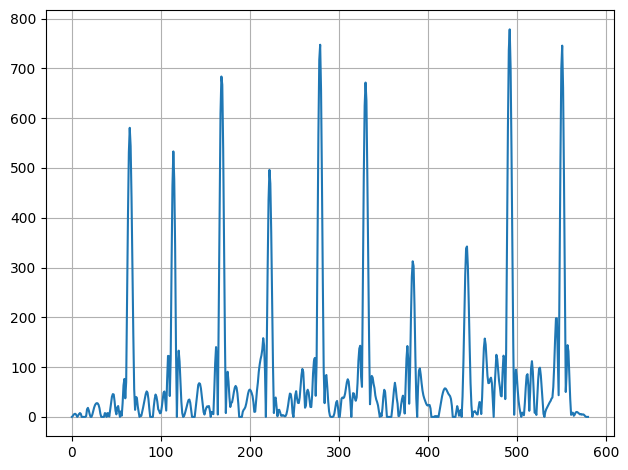

In [110]:
from scipy.signal import medfilt

signal = decim_signal_all_hand[7]
med = medfilt(signal, kernel_size=31)
detail = signal - med
#dy = np.gradient((detail))
#dy = np.where(dy>1, 1, dy)

plt.plot(np.abs(detail))
plt.grid()

plt.tight_layout()
#plt.savefig("10 шагов 1 детекция шага.png", dpi=300)
plt.show()

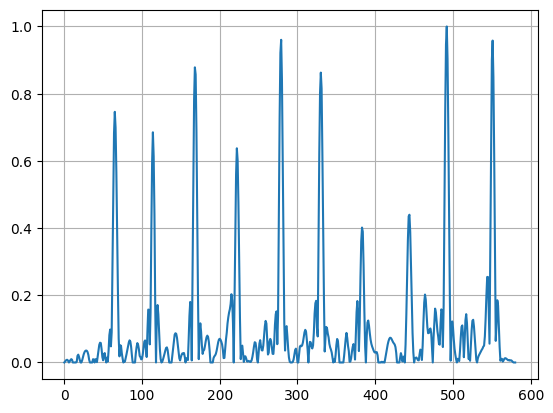

In [112]:
#signal_check = moving_average(abs(dyX),4)
signal_check = np.abs(detail)
signal_check = (signal_check/np.max(signal_check)) #
plt.plot(signal_check)
#plt.plot(dyX)
plt.grid()
plt.show()

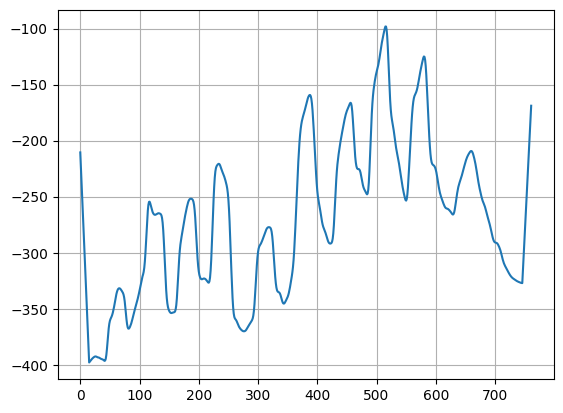

In [204]:
plt.plot(smooth)
plt.grid()

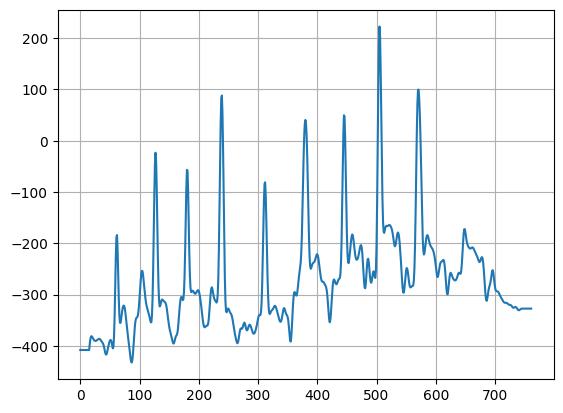

In [206]:
plt.plot(signal)
plt.grid()

In [216]:
detail.shape

(732,)

In [36]:
signal1 = decim_signal_all_hand[2]
signal2 = decim_signal_all_hand[4]
signal3 = decim_signal_all_hand[7]
signal4 = decim_signal_all_hand[1]

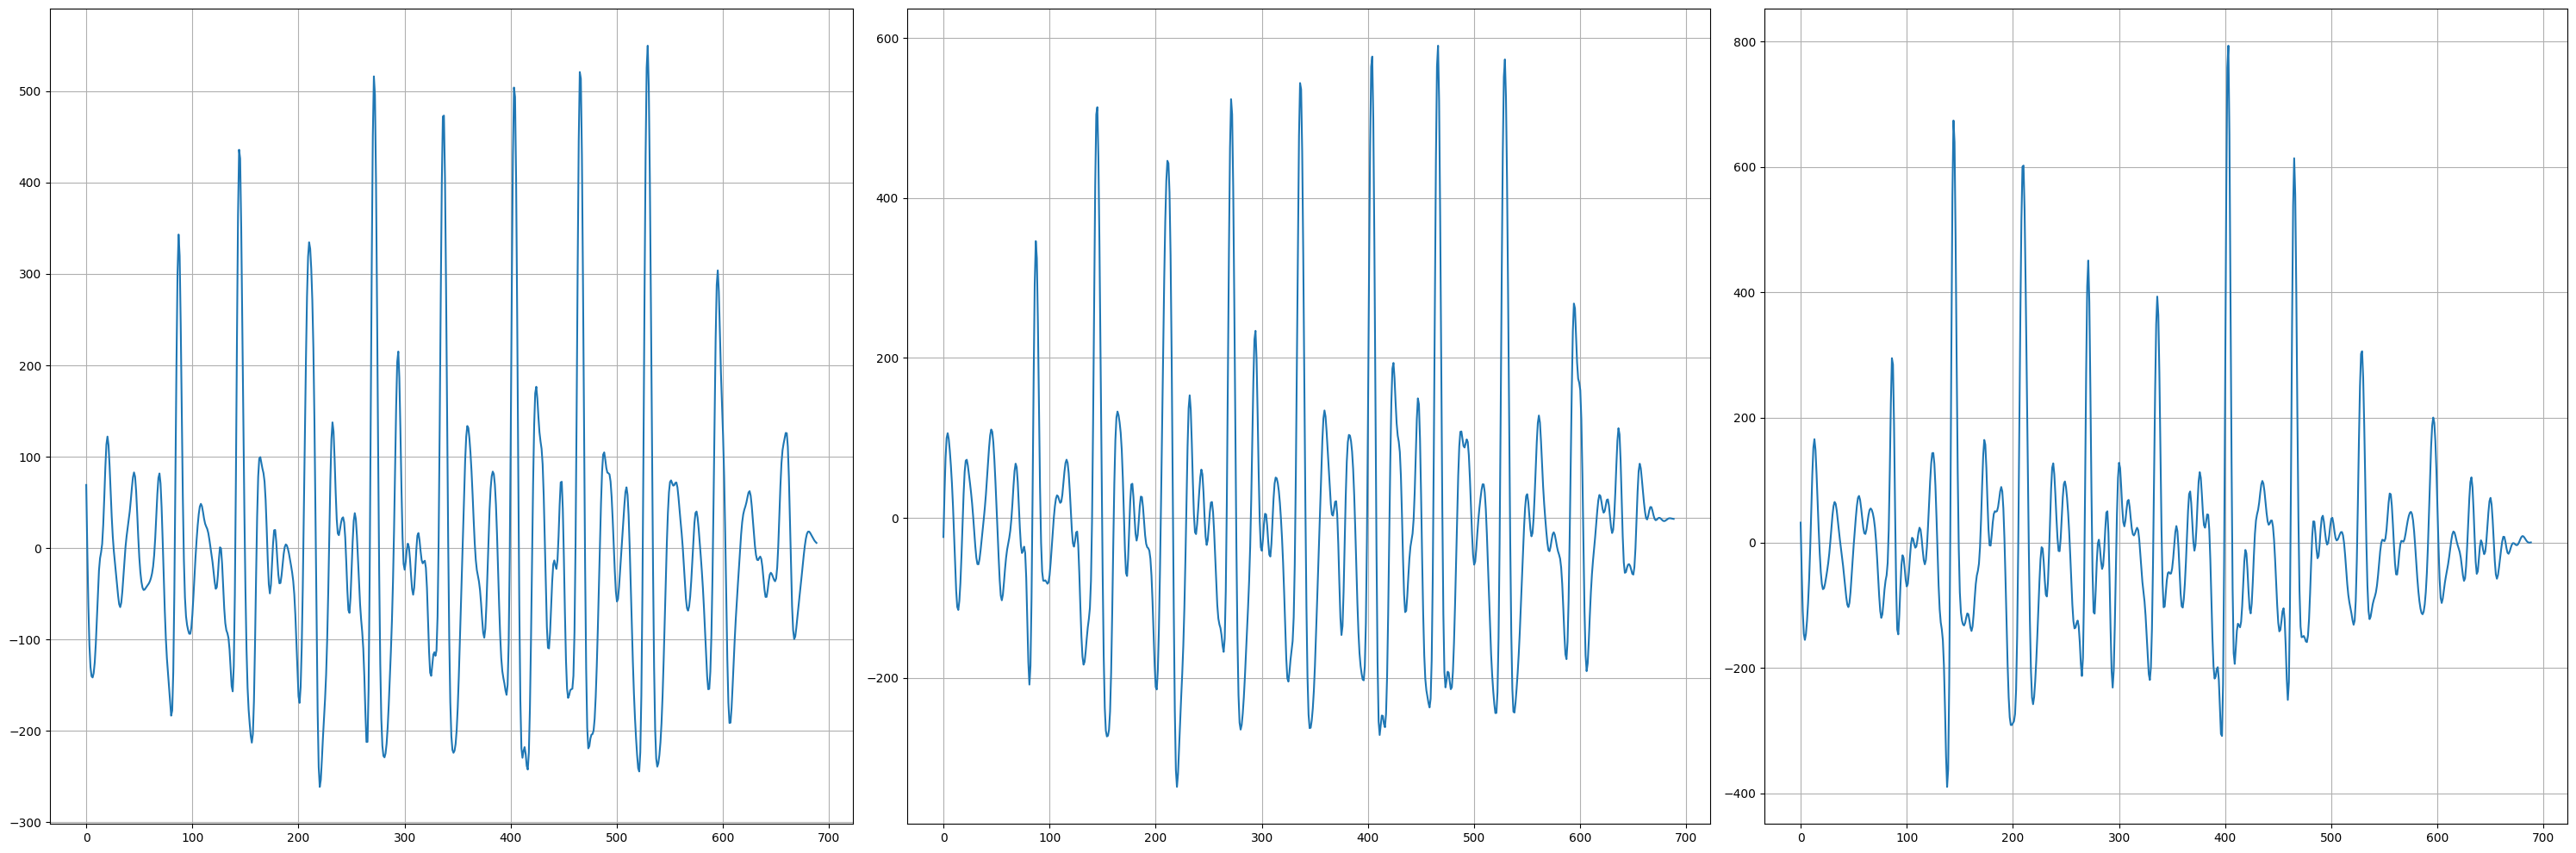

In [52]:
#signal = signal2

def prep_signal(signal):
    win = 31 
    signal = np.pad(signal, win//2, mode='edge')
    smooth = np.convolve(signal, np.ones(win)/win, mode='same')

    detail = (signal - smooth)[win//2:-win//2 +1]

    if np.abs(np.max(detail))>np.abs(np.min(detail)):
        x = detail#(np.where(detail<0,0,detail))
    else:
        x = -detail #(np.where(-detail<0,0,-detail))

    return x

def prep_signal2(signal):
    signal = signal- np.mean(signal)
    if np.abs(np.max(detail))>np.abs(np.min(detail)):
        x = signal#(np.where(detail<0,0,detail))
    else:
        x = -signal #(np.where(-detail<0,0,-detail))
    return  x 

signal1 = prep_signal(signal1)
signal2 = prep_signal(signal2)
signal3 = prep_signal(signal3)
signal4 = prep_signal(signal4)

plt.figure(figsize=(30, 10))  # размер всей фигуры

plt.subplot(1, 3, 1)
plt.plot(signal1)
plt.grid()

plt.subplot(1, 3, 2)
plt.plot(signal2)
plt.grid()

plt.subplot(1, 3, 3)
plt.plot(signal3)
plt.grid()

plt.tight_layout()
#plt.savefig("10 шагов 1 детекция шага.png", dpi=300)
plt.show()


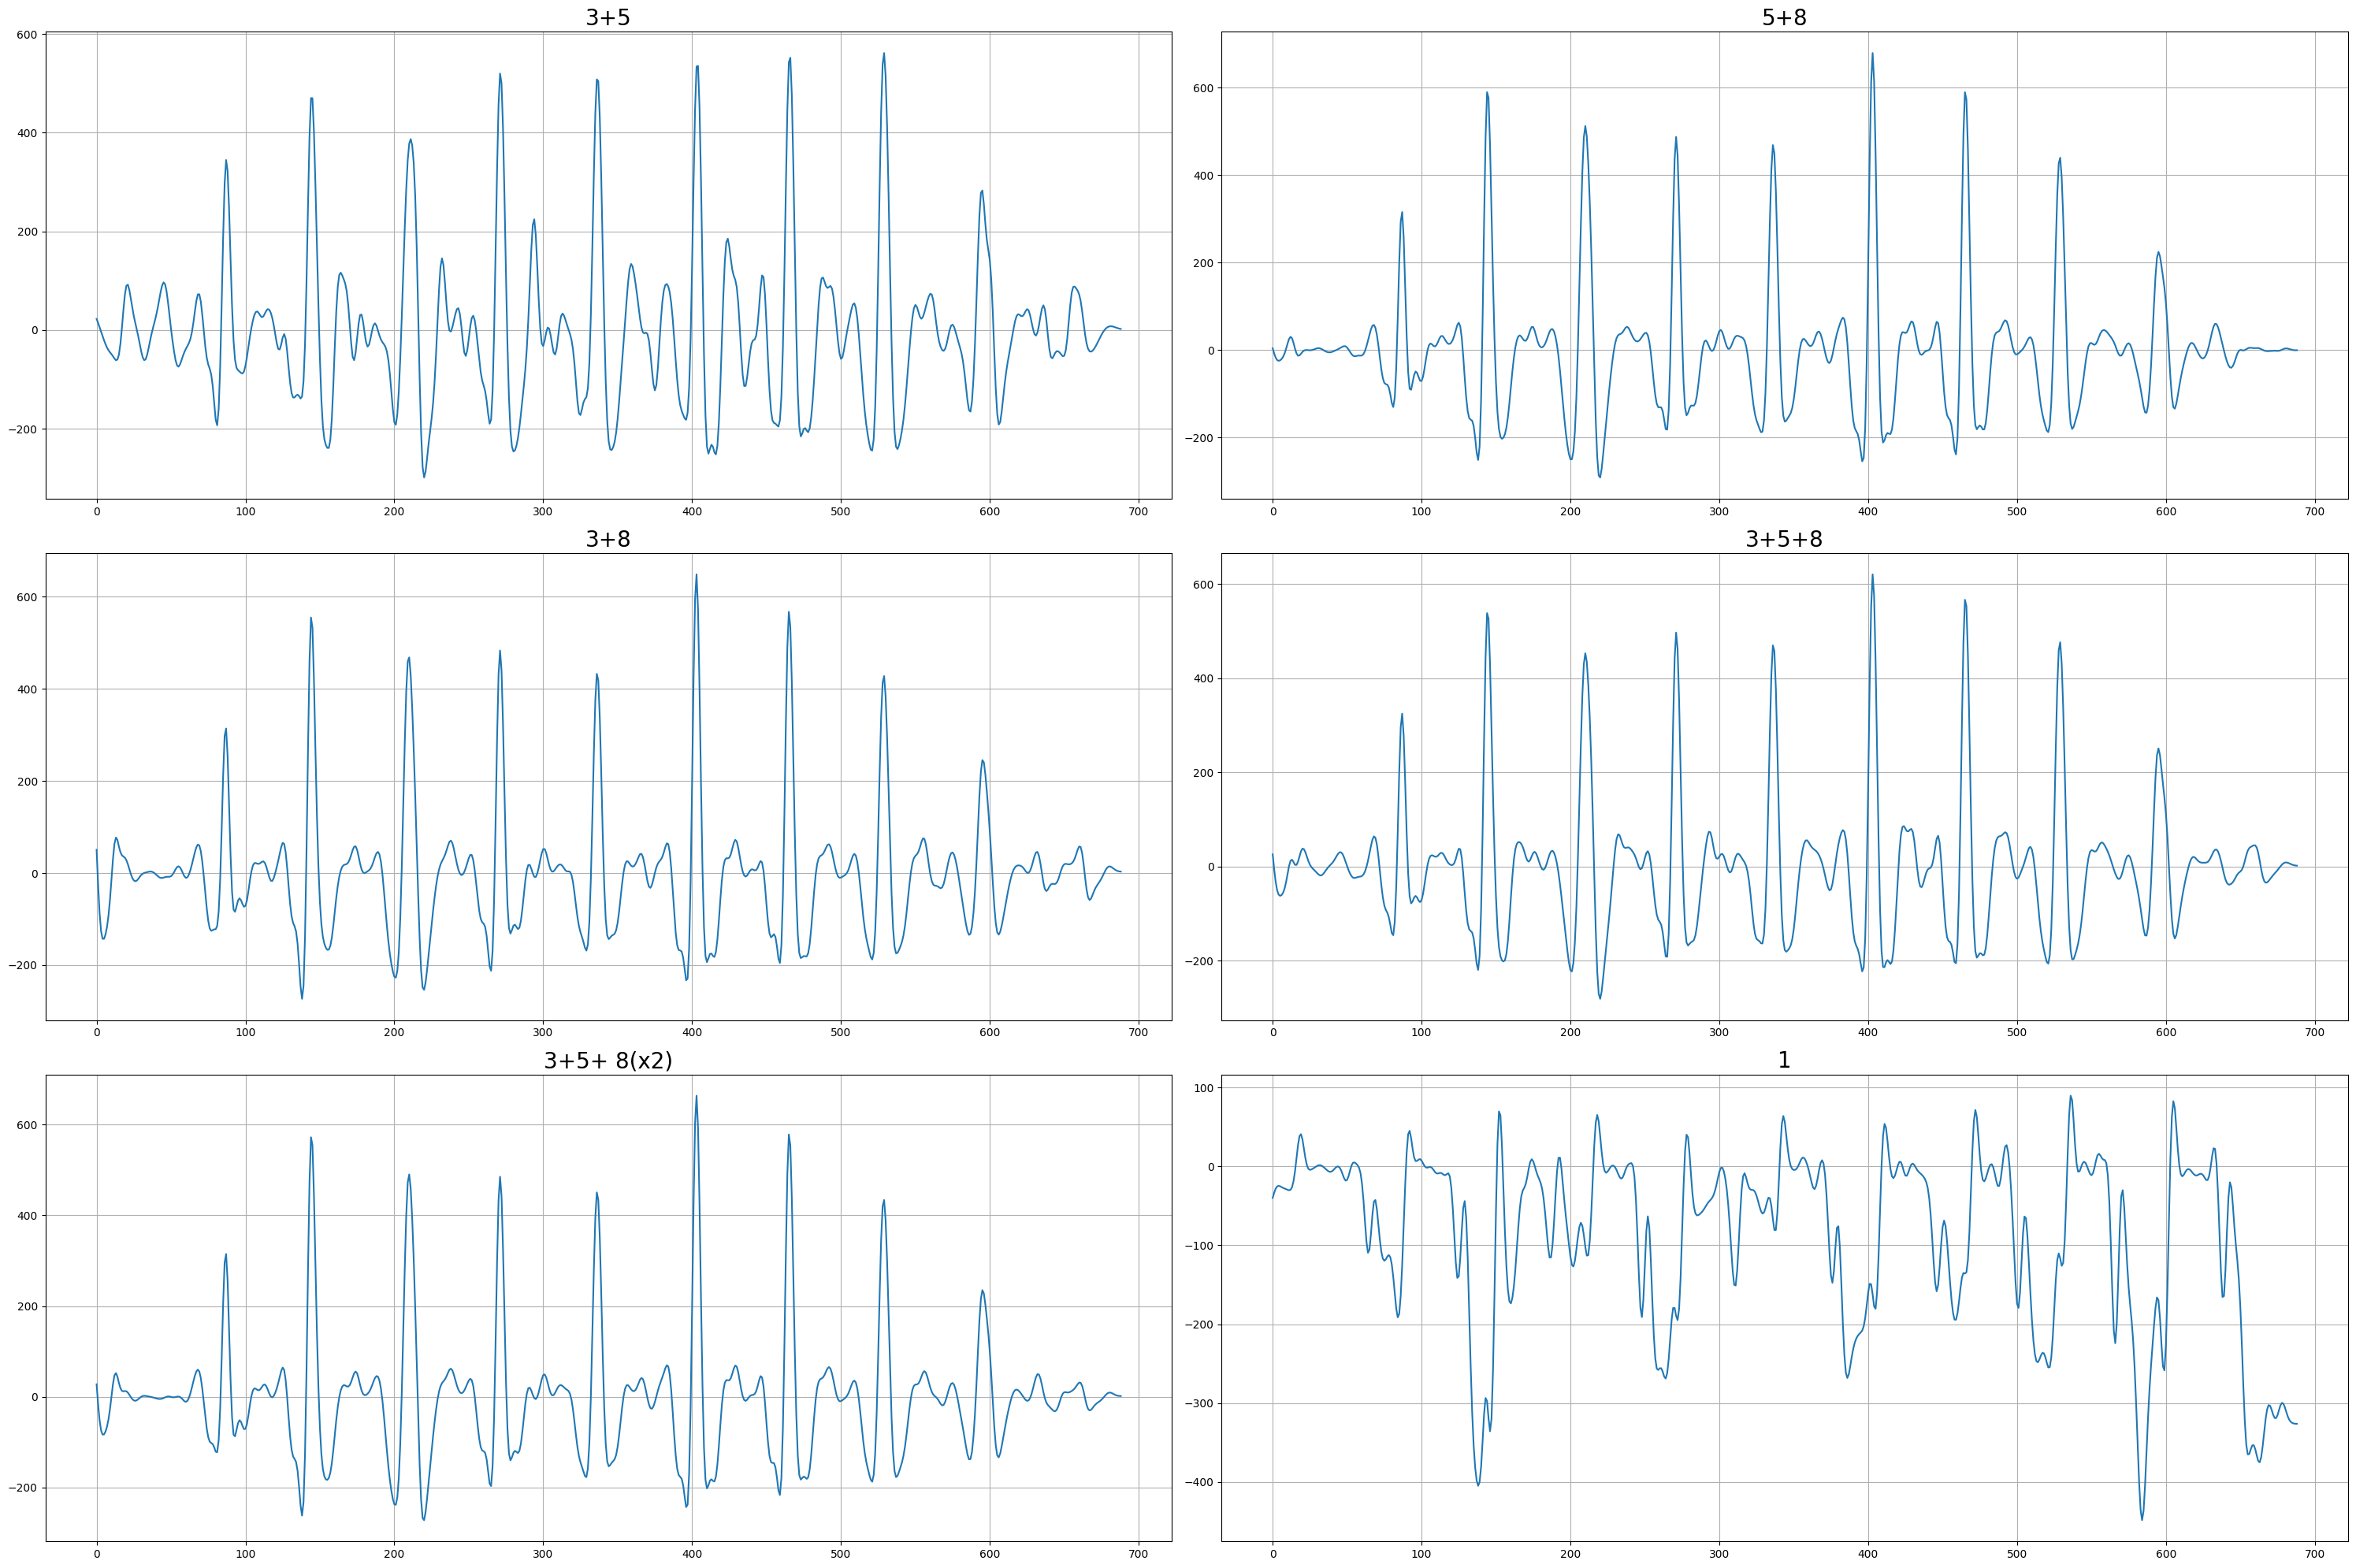

In [53]:
plt.figure(figsize=(30, 20))  # размер всей фигуры

plt.subplot(3, 2, 1)
plt.plot((signal1+signal2)/2)
plt.title("3+5", fontsize=20)
plt.grid()

plt.subplot(3, 2, 2)
plt.plot((signal2+signal3)/2)
plt.title("5+8", fontsize=20)
plt.grid()

plt.subplot(3, 2, 3)
plt.plot((signal3+signal1)/2)
plt.title("3+8", fontsize=20)
plt.grid()

plt.subplot(3, 2, 4)
plt.title("3+5+8", fontsize=20)
plt.plot((signal3+signal1+signal2)/3)
plt.grid()

plt.subplot(3, 2, 5)
plt.title("3+5+ 8(x2)", fontsize=20)
plt.plot((2*signal3+signal1+signal2)/4)
plt.grid()

plt.subplot(3, 2, 6)
plt.title("1", fontsize=20)
plt.plot(decim_signal_all_hand[0])
plt.grid()

plt.tight_layout()
plt.savefig("пятка комбинации.png", dpi=300)
plt.show()


In [40]:
from scipy.signal import find_peaks

treshold = 100
peaks, _ = find_peaks((signal3+signal1+signal2)/3, distance=8, height=treshold)

In [41]:
peaks

array([ 46, 112, 165, 223, 296, 364, 430, 490, 555], dtype=int64)

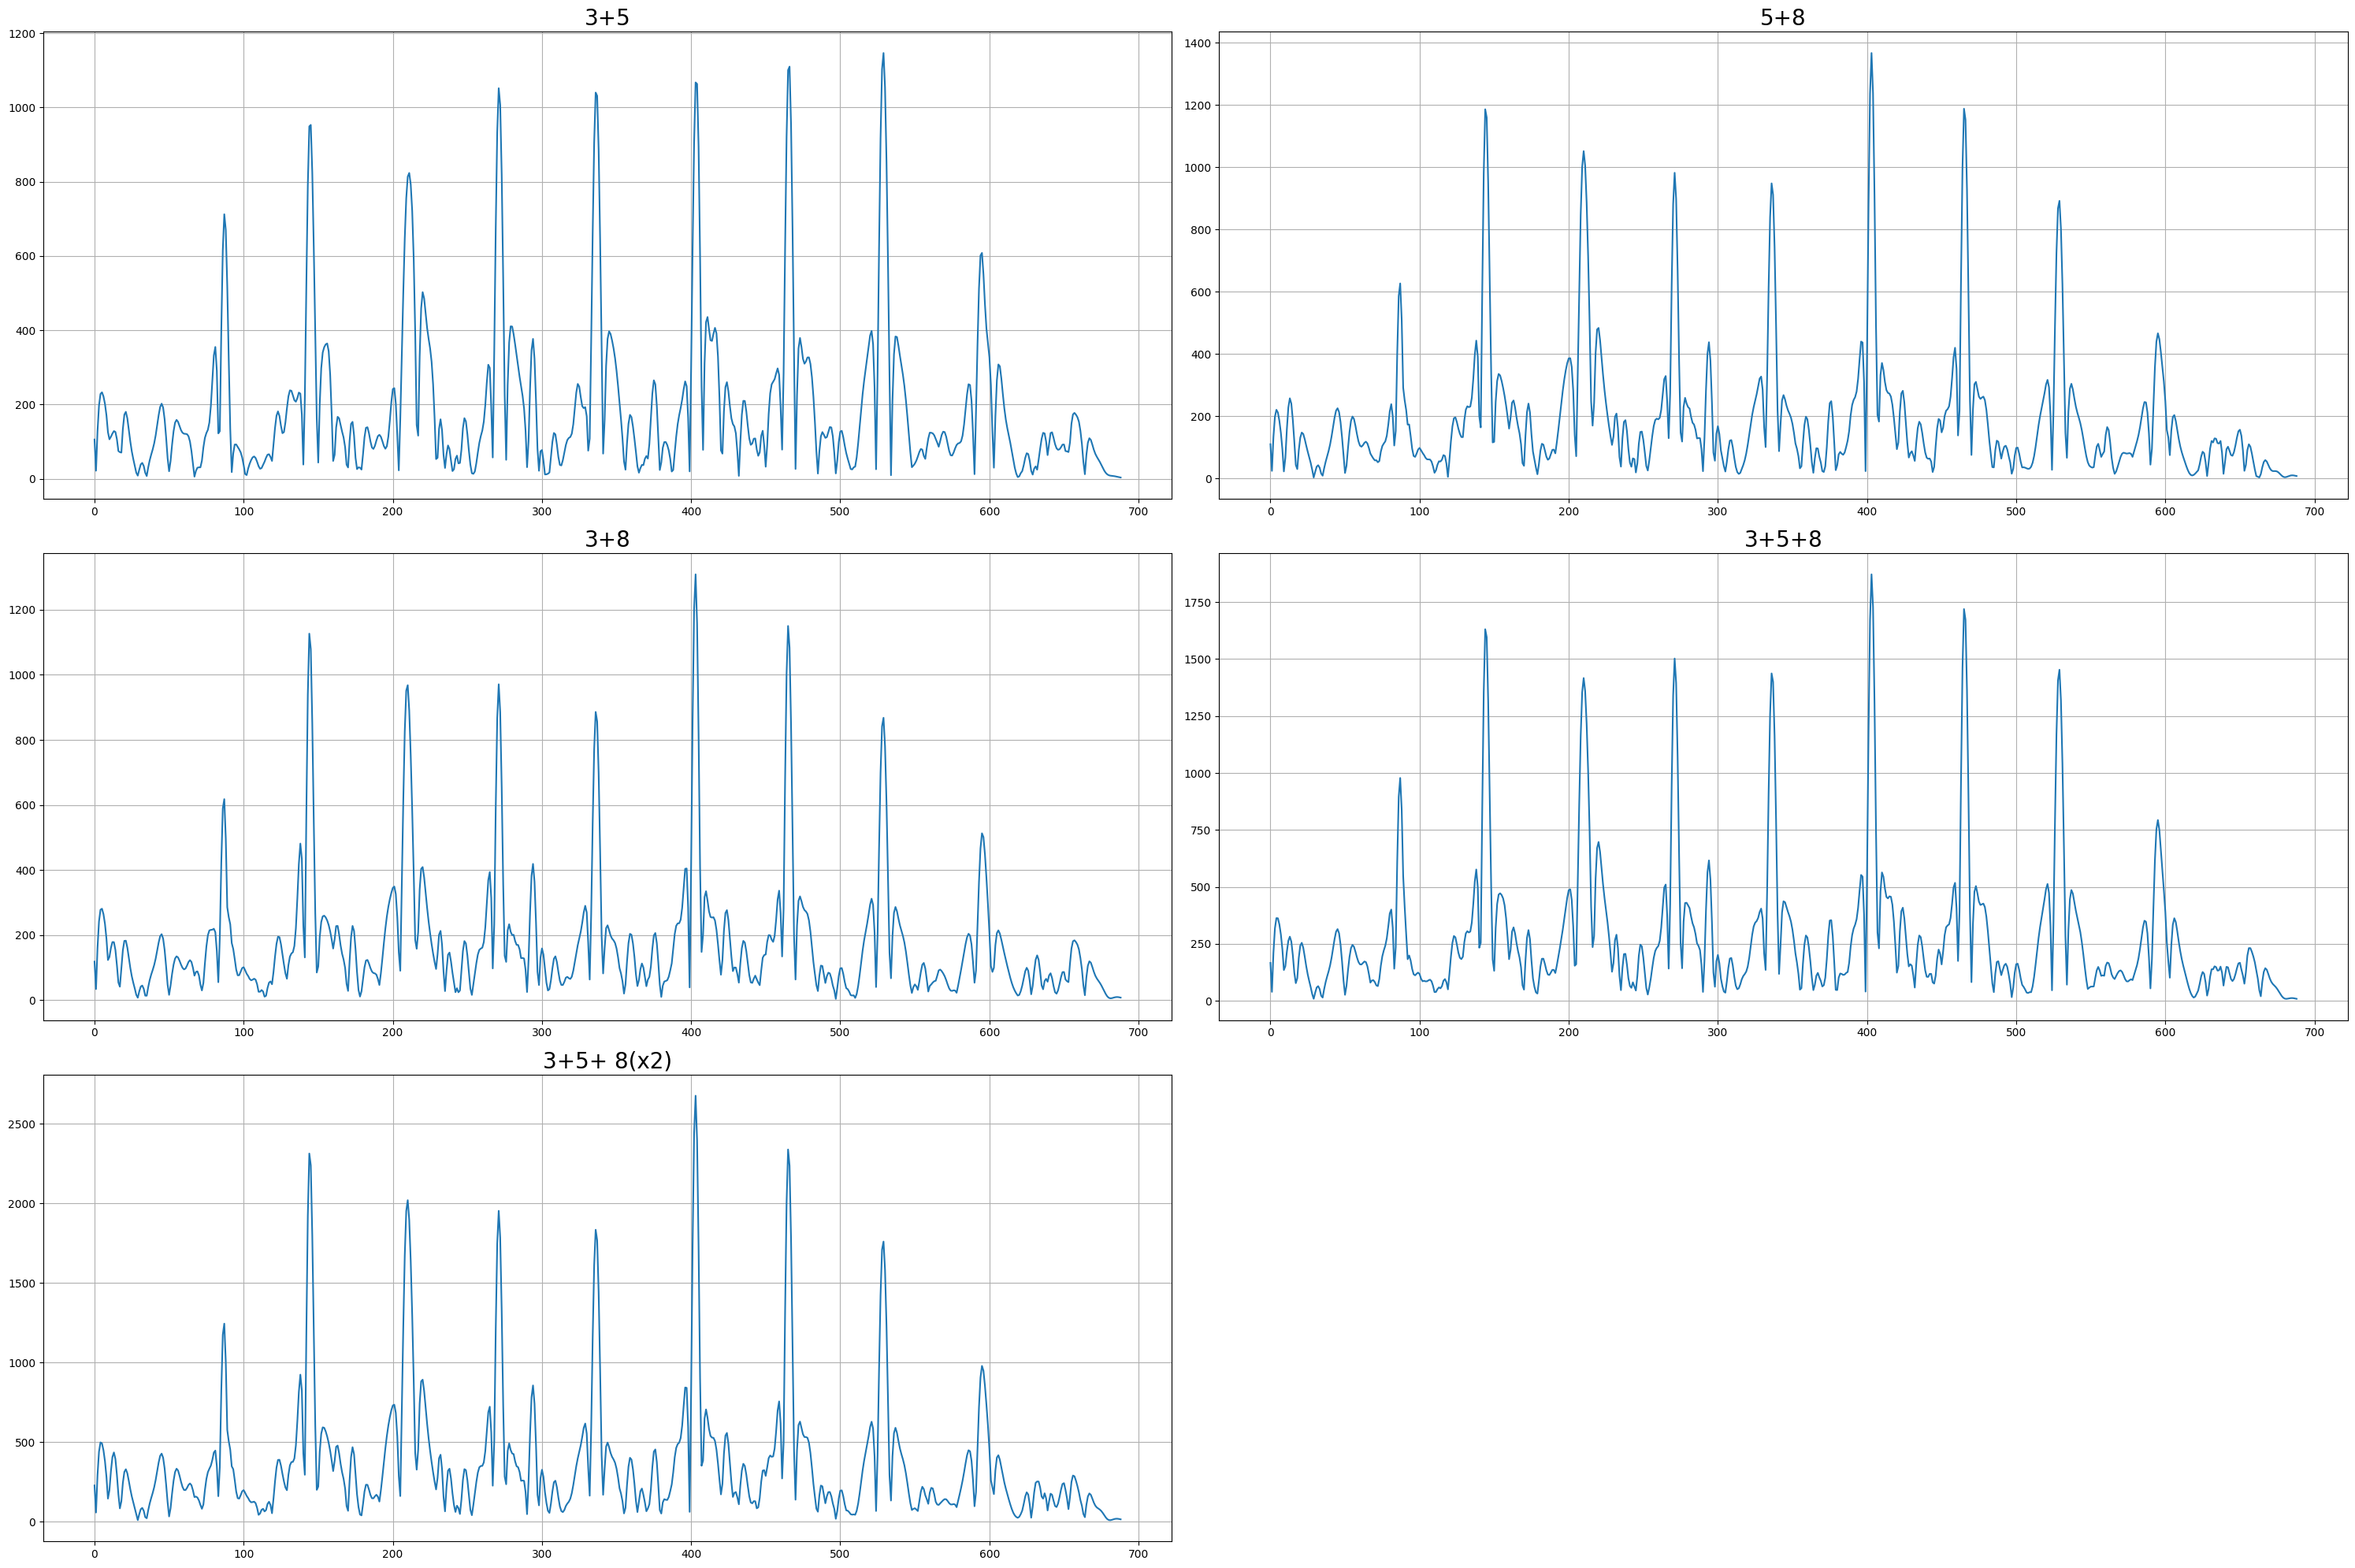

In [1058]:
signal1 = np.abs(signal1)
signal2 = np.abs(signal2)
signal3 = np.abs(signal3)

plt.figure(figsize=(30, 20))  # размер всей фигуры

plt.subplot(3, 2, 1)
plt.plot(signal1+signal2)
plt.title("3+5", fontsize=20)
plt.grid()

plt.subplot(3, 2, 2)
plt.plot(signal2+signal3)
plt.title("5+8", fontsize=20)
plt.grid()

plt.subplot(3, 2, 3)
plt.plot(signal3+signal1)
plt.title("3+8", fontsize=20)
plt.grid()

plt.subplot(3, 2, 4)
plt.title("3+5+8", fontsize=20)
plt.plot(signal3+signal1+signal2)
plt.grid()

plt.subplot(3, 2, 5)
plt.title("3+5+ 8(x2)", fontsize=20)
plt.plot(2*signal3+signal1+signal2)
plt.grid()

plt.tight_layout()
plt.savefig("пятка с модулем.png", dpi=300)
plt.show()


MB TOP

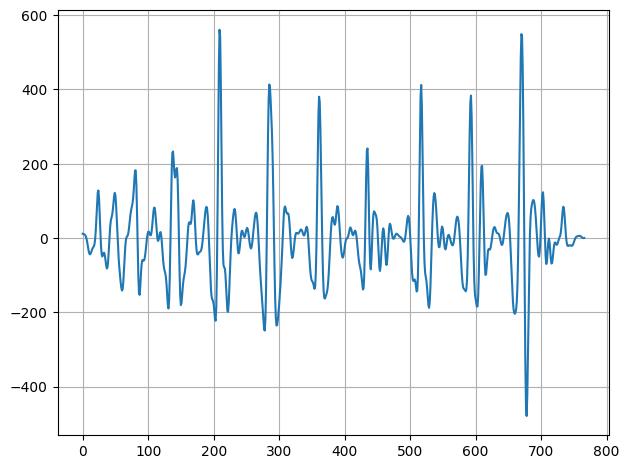

In [699]:
signal = signal2#decim_signal_all_hand[4]
#signal[::8] = 500
#signal[1::8] = 600
#signal[2::8] = 100
#signal = np.abs(signal - np.mean(signal))
# --- сглаживание ---
win = 31  # ширина окна — регулирует "степень сглаживания"
signal = np.pad(signal, win//2, mode='edge')
smooth = np.convolve(signal, np.ones(win)/win, mode='same')

# --- выделение пикового компонента ---
detail = (signal - smooth)[win//2:-win//2 +1]

#if np.abs(np.max(detail))>np.abs(np.min(detail)):
#    x = (np.where(detail<0,0,detail))
#else:
#    x = (np.where(-detail<0,0,-detail))

#win = 3
#signal = x
#signal = np.pad(signal, win//2, mode='edge')
#smooth = np.convolve(signal, np.ones(win)/win, mode='same')

# --- выделение пикового компонента ---
#detail = (smooth)[win//2:-win//2 +1]
#signal = np.abs(detail)

#signal = np.pad(signal, win//2, mode='edge')
#smooth = np.convolve(signal, np.ones(win)/win, mode='same')

# --- выделение пикового компонента ---
#detail = (signal - smooth)[win//2:-win//2 +1]

plt.plot(detail)
plt.grid()

plt.tight_layout()
#plt.savefig("10 шагов 1 детекция шага.png", dpi=300)
plt.show()

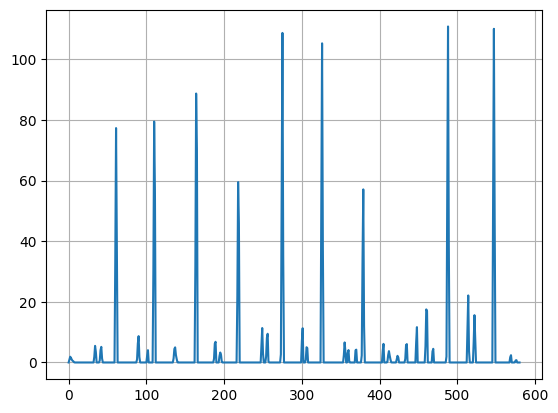

In [517]:
if np.abs(np.max(detail))>np.abs(np.min(detail)):
    x = np.gradient(np.where(detail<0,0,detail))
else:
    x = np.gradient(np.where(-detail<0,0,-detail))

y = np.gradient(np.where(x<0,0,x))
plt.plot(np.where(y<0,0,y))
plt.grid()

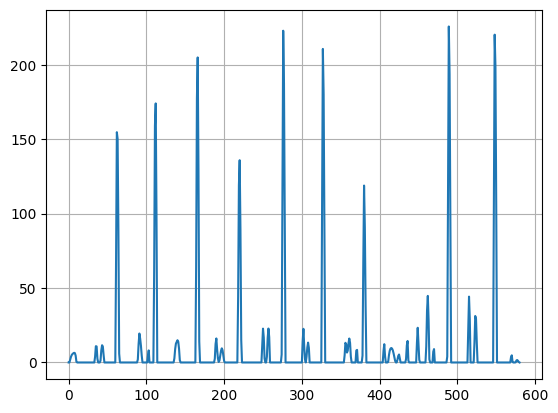

In [518]:
plt.plot(np.where(x<0,0,x))
plt.grid()

In [279]:
peaks, _ = find_peaks(np.where(x<0,0,x), distance=5,height=20)

In [280]:
print(peaks.shape)

(16,)


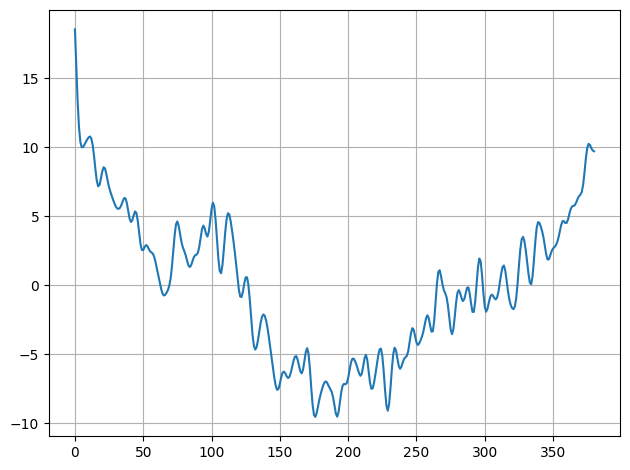

In [176]:
signal = decim_signal_all_hand[4]

detail = signal - np.mean(signal)

plt.plot(detail)
plt.grid()

plt.tight_layout()
#plt.savefig("10 шагов 1 детекция шага.png", dpi=300)
plt.show()